# Sequence baseline for EHRSHOT-MEDS: raw vs chronic-code compressed sequences

Цель ноутбука — построить воспроизводимый sequence baseline для задач `guo_readmission` и `guo_icu` и проверить, как разные способы сжатия повторяющихся chronic-like диагнозов влияют на длину patient sequences и качество risk prediction.

Сравниваются пять версий входных последовательностей:

* `raw` — исходная история событий пациента до `prediction_time`;
* `compressed_dedup` — дедупликация повторяющихся chronic-like диагнозов внутри reconstructed visit / календарного дня;
* `compressed_first_last` — замена устойчивых повторов chronic-like диагнозов на первое и последнее появление;
* `compressed_condition_era` — замена устойчивых повторов на начало и конец condition era;
* `compressed_hybrid` — адаптивное сочетание `dedup`, `first-last` и `condition-era`.

Compression применяется только к empirical chronic-like diagnosis codes, выделенным в предыдущем audit notebook. Остальные события пациента сохраняются без изменений.

Модели:

* `GRU_1L`, `GRU_2L`;
* `LSTM_1L`, `LSTM_2L`;
* `RETAIN_lite`.

Основное правило против leakage:

```text
event.time <= prediction_time
```

Одна строка итогового sequence parquet соответствует одному prediction example.

## 0. Setup

Ожидаемая структура данных:

```text
EHRSHOT_MEDS/
  data/data.parquet
  metadata/subject_splits.parquet
  labels/guo_readmission/labels.parquet
  labels/guo_icu/labels.parquet
```

Итоговые sequence datasets сохраняются в:

```text
ehrshot_sequence_datasets/
  guo_readmission/raw/examples.parquet
  guo_readmission/raw/vocab.json
  guo_readmission/raw/metadata.json
  guo_readmission/compressed/examples.parquet
  ...
  guo_icu/raw/examples.parquet
  ...
```


In [2]:
# import sys
# !{sys.executable} -m pip install "clearml[s3]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.2/15.2 MB 1.3 MB/s  0:00:11m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [boto3]re]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3.12 install --upgrade pip


In [1]:
from pathlib import Path
import json
import math
import random
import warnings
from copy import deepcopy

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    precision_recall_curve,
)
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

EHRSHOT_ROOT = Path("EHRSHOT_MEDS")
DATA_PATH = EHRSHOT_ROOT / "data" / "data.parquet"
SPLITS_PATH = EHRSHOT_ROOT / "metadata" / "subject_splits.parquet"
LABELS_DIR = EHRSHOT_ROOT / "labels"

SEQUENCE_DATA_DIR = Path("ehrshot_sequence_datasets")
RESULTS_DIR = Path("ehrshot_sequence_results")
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"

for p in [SEQUENCE_DATA_DIR, RESULTS_DIR, CHECKPOINT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), f"Не найден data.parquet: {DATA_PATH}"
assert SPLITS_PATH.exists(), f"Не найден subject_splits.parquet: {SPLITS_PATH}"
assert LABELS_DIR.exists(), f"Не найден labels dir: {LABELS_DIR}"

SELECTED_TASKS = {
    "guo_readmission": {
        "task_description": "30-day readmission after discharge",
        "index_time": "23:59 в день выписки пациента",
        "target": "Повторная госпитализация после выписки",
        "horizon": "30 дней после выписки",
    },
    "guo_icu": {
        "task_description": "ICU transfer during current admission",
        "index_time": "23:59 в день госпитализации / admission",
        "target": "Перевод пациента в ICU",
        "horizon": "Текущая госпитализация / admission episode",
    },
}

SEQUENCE_VERSIONS = [
    "raw",
    "compressed_dedup",
    "compressed_first_last",
    "condition_era_90",
    "condition_era_180",
    "state_duration_90",
    "state_duration_180",
]

# Для прозрачности сохраняем и token_ids, и исходные code strings.
# Если parquet получится слишком большим, можно поставить False и оставить только token_ids.
KEEP_CODE_STRINGS_IN_PARQUET = True

# Если True, пересобираем sequence datasets даже при наличии файлов.
REBUILD_SEQUENCE_DATASETS = True

CHRONIC_CODE_MODE = "strong_only"
# варианты:
# "strong_only"
# "strong_plus_possible"

RUN_MODEL_NAMES = ["GRU_1L", "GRU_2L", "LSTM_1L", "LSTM_2L", "RETAIN_lite"]

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

MAX_LEN = 512
BATCH_SIZE = 64
NUM_WORKERS = 0

# Быстрый debug режим: поставить число, например 500, чтобы проверить pipeline.
MAX_TRAIN_EXAMPLES = None
MAX_EVAL_EXAMPLES = None

N_EPOCHS = 12
PATIENCE = 3
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
SAVE_MODEL_CHECKPOINTS = True

In [ ]:
from clearml import Task

CLEARML_PROJECT = "pershin-medailab/EHR_Risk_Profiling/EHRSHOT"
CLEARML_TASK_NAME = "sequence_baseline_notebook_v1"
CLEARML_OUTPUT_URI = "s3://api.blackhole2.ai.innopolis.university:443/pershin-medailab"

task = Task.init(
    project_name=CLEARML_PROJECT,
    task_name=CLEARML_TASK_NAME,
    output_uri=CLEARML_OUTPUT_URI,
)

clearml_config = {
    "rebuild_sequence_datasets": True,
    "sequence_versions": SEQUENCE_VERSIONS,
    "run_model_names": RUN_MODEL_NAMES,
    "max_len": MAX_LEN,
    "batch_size": BATCH_SIZE,
    "n_epochs": N_EPOCHS,
    "patience": PATIENCE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "chronic_code_mode": CHRONIC_CODE_MODE,
}

clearml_config = task.connect(clearml_config)

Retrying (Retry(total=239, connect=240, read=240, redirect=240, status=240)) after connection broken by 'SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1000)'))': /auth.login
Retrying (Retry(total=238, connect=240, read=239, redirect=240, status=240)) after connection broken by 'ReadTimeoutError("HTTPSConnectionPool(host='api.clearai.innopolis.university', port=443): Read timed out. (read timeout=3.0)")': /auth.login
Retrying (Retry(total=237, connect=240, read=238, redirect=240, status=240)) after connection broken by 'ReadTimeoutError("HTTPSConnectionPool(host='api.clearai.innopolis.university', port=443): Read timed out. (read timeout=3.0)")': /auth.login


ClearML Task: created new task id=84e2aef056324facb0d0dcc12baa9562
2026-06-17 14:10:06,358 - clearml.Task - INFO - Storing jupyter notebook directly as code
CLEARML-SERVER new package available: UPGRADE to v2.4.0 is recommended!
Release Notes:
### New features and improvements
- Add show/hide matching filter control to UI Task Scalars and Plots ([ClearML #744](https://github.com/clearml/clearml/issues/744), [ClearML #1253](https://github.com/clearml/clearml/issues/1253))
- Task Comparison view: Display task color indicators in task list instead of task legend ([ClearML #1461](https://github.com/clearml/clearml/issues/1461))
- Add support for setting task type during UI task creation ([ClearML Web #115](https://github.com/clearml/clearml-web/issues/115))
- Add configuration-based overrides for default Elasticsearch mappings
- Add UI task clone options to reset Python requirements
- Update Elastic to version 8.19.9
- Make Task Repository URL in Task Execution tab clickable
- Support shor

ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


Retrying (Retry(total=237, connect=238, read=239, redirect=240, status=240)) after connection broken by 'NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x49c404aa0>: Failed to resolve 'api.clearai.innopolis.university' ([Errno 8] nodename nor servname provided, or not known)")': /v2.23/tasks.get_all
Retrying (Retry(total=236, connect=237, read=239, redirect=240, status=240)) after connection broken by 'NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x367005400>: Failed to resolve 'api.clearai.innopolis.university' ([Errno 8] nodename nor servname provided, or not known)")': /v2.23/tasks.get_all
Retrying (Retry(total=237, connect=237, read=240, redirect=240, status=240)) after connection broken by 'NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x367005100>: Failed to establish a new connection: [Errno 61] Connection refused')': /v2.23/events.add_batch
Retrying (Retry(total=236, connect=236, read=240, redirect=240, status=240)) 

2026-06-17 18:32:05,043 - clearml.storage - INFO - Uploading: 359.44MB from /var/folders/v5/_5rgnv1s17zbz3kxbhgwr18r0000gn/T/ehrshot_sequence_results.qhvuur5f.zip


                                     0% | 438.00/? MB [00:14<00:00, 29.56MB/s]: 
Retrying (Retry(total=237, connect=240, read=240, redirect=240, status=240)) after connection broken by 'SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1000)'))': /v2.23/events.add_batch
Retrying (Retry(total=236, connect=240, read=240, redirect=240, status=240)) after connection broken by 'SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1000)'))': /v2.23/events.add_batch
Retrying (Retry(total=235, connect=240, read=240, redirect=240, status=240)) after connection broken by 'SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1000)'))': /v2.23/events.add_batch
Retrying (Retry(total=234, connect=240, read=240, redirect=240, status=240)) after connection broken by 'SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred

2026-06-17 19:05:59,108 - clearml.Task - WARNING - ### TASK STOPPED - USER ABORTED - STATUS CHANGED ###


In [3]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("DEVICE:", DEVICE)

DEVICE: mps


## 1. Load events, splits and labels

Target берется из label-файлов. Split берется из `subject_splits.parquet`, чтобы сравнение с табличным baseline было честным.


In [4]:
events_lf_raw = pl.scan_parquet(str(DATA_PATH))
splits = pl.read_parquet(SPLITS_PATH)

task_to_label_file = {
    p.parent.name: p
    for p in sorted(LABELS_DIR.glob("*/labels.parquet"))
}

for task_name in SELECTED_TASKS:
    assert task_name in task_to_label_file, f"Не найден label file для {task_name}"

print("Events schema:")
print(events_lf_raw.collect_schema())

print("\nSplits:")
display(splits.group_by("split").agg(pl.len().alias("n_subjects")).to_pandas())

print("\nSelected label files:")
for task_name in SELECTED_TASKS:
    print(task_name, "->", task_to_label_file[task_name])

Events schema:
Schema({'subject_id': Int64, 'time': Datetime(time_unit='us', time_zone=None), 'code': String, 'numeric_value': Float32, 'text_value': String, 'unit': String, 'omop_table': String})

Splits:


,split,n_subjects
0,held_out,2212
1,tuning,2232
2,train,2295



Selected label files:
guo_readmission -> EHRSHOT_MEDS/labels/guo_readmission/labels.parquet
guo_icu -> EHRSHOT_MEDS/labels/guo_icu/labels.parquet


In [5]:
def detect_label_col(lf: pl.LazyFrame) -> str:
    candidate_cols = [
        "boolean_value",
        "integer_value",
        "float_value",
        "categorical_value",
        "label",
        "value",
    ]
    schema_cols = lf.collect_schema().names()
    existing = [c for c in candidate_cols if c in schema_cols]

    if not existing:
        raise ValueError(f"No known label column found. Schema: {schema_cols}")

    non_null_counts = (
        lf.select([pl.col(c).is_not_null().sum().alias(c) for c in existing])
        .collect()
        .to_pandas()
        .iloc[0]
    )
    non_null_cols = non_null_counts[non_null_counts > 0]
    if len(non_null_cols) == 0:
        raise ValueError(f"All candidate label columns are null. Existing: {existing}")

    return non_null_cols.index[0]


def load_task_labels(task_name: str) -> pl.DataFrame:
    label_path = task_to_label_file[task_name]
    lf = pl.scan_parquet(str(label_path))
    label_col = detect_label_col(lf)

    labels = (
        pl.read_parquet(label_path)
        .with_row_index("row_id")
        .with_columns([
            pl.col(label_col).cast(pl.Int8).alias("label"),
            pl.lit(task_name).alias("task"),
        ])
        .join(splits, on="subject_id", how="left")
        .select([
            "task",
            "row_id",
            "subject_id",
            "prediction_time",
            "label",
            "split",
        ])
    )

    return labels


labels_by_task = {
    task_name: load_task_labels(task_name)
    for task_name in SELECTED_TASKS
}

problem_rows = []

for task_name, labels in labels_by_task.items():
    meta = SELECTED_TASKS[task_name]
    n_examples = labels.height
    n_patients = labels["subject_id"].n_unique()
    n_positive = int(labels["label"].sum())

    problem_rows.append({
        "task": task_name,
        "index_time": meta["index_time"],
        "target": meta["target"],
        "horizon": meta["horizon"],
        "n_examples": n_examples,
        "n_patients": n_patients,
        "n_positive": n_positive,
        "event_rate": n_positive / n_examples,
        "event_rate_percent": 100 * n_positive / n_examples,
    })

problem_df = pd.DataFrame(problem_rows)
display(problem_df)

,task,index_time,target,horizon,n_examples,n_patients,n_positive,event_rate,event_rate_percent
0,guo_readmission,23:59 в день выписки пациента,Повторная госпитализация после выписки,30 дней после выписки,7003,3718,911,0.130087,13.008711
1,guo_icu,23:59 в день госпитализации / admission,Перевод пациента в ICU,Текущая госпитализация / admission episode,6491,3617,290,0.044677,4.467725


## 2. Sequence dataset format

Сохраняем не просто временный объект для одной модели, а переиспользуемый датасет:

- `token_ids` — последовательность id событий;
- `codes` — исходные/синтетические коды, чтобы можно было делать аудит;
- `days_before_prediction` — сколько дней до cutoff было событие;
- `delta_days` — промежуток в днях от предыдущего события;
- `numeric_values` — числовые значения событий, пока не используются в baseline, но нужны для будущего missing-aware блока;
- `label`, `split`, `subject_id`, `row_id`, `prediction_time` — metadata.

Vocab строится только по `train`, чтобы не подглядывать в `tuning`/`held_out` через новые коды.


In [6]:
SPECIAL_TOKENS = {
    "<PAD>": 0,
    "<UNK>": 1,
    "<CLS>": 2,
}
PAD_ID = SPECIAL_TOKENS["<PAD>"]
UNK_ID = SPECIAL_TOKENS["<UNK>"]
CLS_ID = SPECIAL_TOKENS["<CLS>"]

# Diagnosis-like rule первого приближения.
# В EHRSHOT-MEDS diagnosis чаще всего приходит как SNOMED-код.
# Если потом найдем более точную OMOP-domain metadata, это место можно заменить без изменения downstream формата.
DIAGNOSIS_LIKE_FAMILIES = [
    "SNOMED",
    "ICD10CM",
    "ICD9CM",
    "ICD10",
    "ICD9",
]

# Compression thresholds.
FIRST_LAST_MIN_POINTS = 2
FIRST_LAST_MIN_SPAN_DAYS = 1
ERA_MIN_POINTS = 3
ERA_MIN_SPAN_DAYS = 30

# Ограничение словаря можно включить, если GPU/CPU тяжело.
# None = все train-коды.
MAX_VOCAB_SIZE = None
MIN_CODE_COUNT = 1

INCLUDE_PREDICTION_TIME = True

In [7]:
def load_chronic_code_whitelist(results_dir: Path, mode: str = "strong_only") -> set[str]:
    strong_path = results_dir / "strong_empirical_chronic_like_diagnosis_codes.csv"
    possible_path = results_dir / "possible_empirical_chronic_like_diagnosis_codes.csv"

    if not strong_path.exists():
        raise FileNotFoundError(
            f"Не найден файл {strong_path}. "
            "Сначала запусти audit notebook и сохрани chronic-like diagnosis codes."
        )

    strong = pd.read_csv(strong_path)
    chronic_codes = set(strong["code"].astype(str))

    if mode == "strong_plus_possible":
        if not possible_path.exists():
            raise FileNotFoundError(f"Не найден файл {possible_path}")
        possible = pd.read_csv(possible_path)
        chronic_codes |= set(possible["code"].astype(str))

    return chronic_codes


CHRONIC_CODE_WHITELIST = load_chronic_code_whitelist(
    Path("ehrshot_copy_forwarding_audit"),
    mode=CHRONIC_CODE_MODE,
)

print("Chronic-like codes for compression:", len(CHRONIC_CODE_WHITELIST))

Chronic-like codes for compression: 444


In [8]:
event_schema = events_lf_raw.collect_schema().names()

VISIT_ANCHOR_MAX_DAYS = 30


def build_visit_anchors_lf() -> pl.LazyFrame:
    """
    Reconstructed visits по той же логике, что в copy-forwarding audit:
    берем только Visit/... коды из visit_occurrence.
    """
    visit_lf = (
        events_lf_raw
        .filter(pl.col("code").cast(pl.Utf8).str.starts_with("Visit/"))
    )

    if "omop_table" in event_schema:
        visit_lf = visit_lf.filter(pl.col("omop_table") == "visit_occurrence")

    visit_anchors_lf = (
        visit_lf
        .select([
            pl.col("subject_id"),
            pl.col("time").alias("visit_time"),
            pl.col("code").cast(pl.Utf8).alias("visit_code"),
        ])
        .group_by(["subject_id", "visit_time"])
        .agg([
            pl.col("visit_code").unique().sort().alias("visit_codes"),
            pl.len().alias("n_visit_rows_at_time"),
        ])
        .sort(["subject_id", "visit_time"])
        .with_columns([
            (
                pl.col("visit_time").cum_count().over("subject_id") - 1
            )
            .cast(pl.Int32)
            .alias("reconstructed_visit_idx"),

            pl.col("visit_time")
            .shift(-1)
            .over("subject_id")
            .alias("next_visit_time"),
        ])
    )

    return visit_anchors_lf


visit_anchors_lf = build_visit_anchors_lf()


def base_events_lf() -> pl.LazyFrame:
    schema = events_lf_raw.collect_schema().names()

    exprs = [
        pl.col("subject_id"),
        pl.col("time"),
        pl.col("code").cast(pl.Utf8).alias("code"),
    ]

    if "numeric_value" in schema:
        exprs.append(pl.col("numeric_value").cast(pl.Float32).alias("numeric_value"))
    else:
        exprs.append(pl.lit(None).cast(pl.Float32).alias("numeric_value"))

    if "text_value" in schema:
        exprs.append(pl.col("text_value").cast(pl.Utf8).alias("text_value"))
    else:
        exprs.append(pl.lit(None).cast(pl.Utf8).alias("text_value"))

    base = (
        events_lf_raw
        .select(exprs)
        .with_columns([
            pl.col("code")
            .str.extract(r"^([^/]+)", 1)
            .fill_null("UNKNOWN")
            .alias("code_family"),

            pl.col("time")
            .dt.date()
            .cast(pl.Utf8)
            .alias("event_day"),
        ])
        .sort(["subject_id", "time"])
    )

    # Привязываем событие к ближайшему предыдущему reconstructed visit anchor.
    base_with_visit = (
        base
        .join_asof(
            visit_anchors_lf.sort(["subject_id", "visit_time"]),
            left_on="time",
            right_on="visit_time",
            by="subject_id",
            strategy="backward",
        )
        .with_columns([
            (
                (pl.col("time") - pl.col("visit_time"))
                .dt.total_hours()
                / 24
            )
            .cast(pl.Float32)
            .alias("days_since_visit_anchor")
        ])
        .with_columns([
            (
                pl.col("reconstructed_visit_idx").is_not_null()
                & pl.col("days_since_visit_anchor").is_not_null()
                & (pl.col("days_since_visit_anchor") >= 0)
                & (pl.col("days_since_visit_anchor") <= VISIT_ANCHOR_MAX_DAYS)
            )
            .alias("has_valid_reconstructed_visit")
        ])
        .with_columns([
            pl.when(pl.col("has_valid_reconstructed_visit"))
            .then(
                pl.concat_str([
                    pl.lit("reconstructed_visit="),
                    pl.col("reconstructed_visit_idx").cast(pl.Utf8),
                ])
            )
            .otherwise(
                pl.concat_str([
                    pl.lit("day="),
                    pl.col("event_day"),
                ])
            )
            .alias("compression_bucket")
        ])
    )

    return base_with_visit


def make_history_lf(labels: pl.DataFrame) -> pl.LazyFrame:
    op = (
        pl.col("time") <= pl.col("prediction_time")
        if INCLUDE_PREDICTION_TIME
        else pl.col("time") < pl.col("prediction_time")
    )

    return (
        labels.lazy()
        .join(base_events_lf(), on="subject_id", how="inner")
        .filter(op)
        .with_columns([
            (
                pl.col("prediction_time") - pl.col("time")
            )
            .dt.total_days()
            .cast(pl.Float32)
            .alias("days_before_prediction"),
        ])
    )


def compressible_chronic_code_expr() -> pl.Expr:
    return pl.col("code").is_in(list(CHRONIC_CODE_WHITELIST))

## 3. Build raw and compressed long event tables

Compression rules первого этапа:

1. `dedup` одинаковых diagnosis-like кодов внутри визита; если visit id нет, внутри календарного дня.
2. `first-last` для повторяющихся diagnosis-like кодов: оставляем только первое и последнее появление.
3. `condition-era` для более устойчивых повторов: заменяем серию повторов на `DX_ERA_START/...` и `DX_ERA_END/...`.

In [9]:
STANDARD_LONG_COLS = [
    "task",
    "row_id",
    "subject_id",
    "prediction_time",
    "label",
    "split",
    "time",
    "code",
    "numeric_value",
    "text_value",
    "days_before_prediction",
    "is_compression_token",
]

EXAMPLE_KEY_COLS = [
    "task",
    "row_id",
    "subject_id",
    "prediction_time",
    "label",
    "split",
]

COMPRESSION_GROUP_COLS = EXAMPLE_KEY_COLS + [
    "code",
    "compression_bucket",
]

CODE_SUMMARY_COLS = EXAMPLE_KEY_COLS + [
    "code",
]


def build_raw_long_lf(labels: pl.DataFrame) -> pl.LazyFrame:
    return (
        make_history_lf(labels)
        .with_columns(
            pl.lit(False).alias("is_compression_token")
        )
        .select(STANDARD_LONG_COLS)
    )


def prepare_chronic_dedup_lf(labels: pl.DataFrame) -> tuple[pl.LazyFrame, pl.LazyFrame]:
    """
    Split history into:
    1. non-compressible events, unchanged;
    2. compressible chronic-like diagnosis events after dedup inside reconstructed visit/day bucket.

    Dedup key:
        task, row_id, subject_id, prediction_time, label, split, code, compression_bucket
    """
    hist = (
        make_history_lf(labels)
        .with_columns(
            compressible_chronic_code_expr()
            .fill_null(False)
            .alias("is_compressible_chronic")
        )
    )

    non_compressed = (
        hist
        .filter(~pl.col("is_compressible_chronic"))
        .with_columns(pl.lit(False).alias("is_compression_token"))
        .select(STANDARD_LONG_COLS)
    )

    chronic_for_compression = (
        hist
        .filter(pl.col("is_compressible_chronic"))
    )

    # Важно: numeric/text берем у самого раннего события внутри bucket.
    chronic_dedup = (
        chronic_for_compression
        .sort(COMPRESSION_GROUP_COLS + ["time", "code"])
        .group_by(COMPRESSION_GROUP_COLS)
        .agg([
            pl.col("time").min().alias("time"),
            pl.col("numeric_value").sort_by("time").first().alias("numeric_value"),
            pl.col("text_value").sort_by("time").first().alias("text_value"),
        ])
        .with_columns([
            (
                pl.col("prediction_time") - pl.col("time")
            )
            .dt.total_days()
            .cast(pl.Float32)
            .alias("days_before_prediction"),

            pl.lit(False).alias("is_compression_token"),
        ])
        .select(STANDARD_LONG_COLS)
    )

    return non_compressed, chronic_dedup


def build_compressed_dedup_long_lf(labels: pl.DataFrame) -> pl.LazyFrame:
    non_compressed, chronic_dedup = prepare_chronic_dedup_lf(labels)

    return (
        pl.concat(
            [non_compressed, chronic_dedup],
            how="vertical_relaxed",
        )
        .sort(["row_id", "time", "code"])
    )


def _compression_token_from_summary(
    summary_lf: pl.LazyFrame,
    token_prefix: str | None,
    time_col: str,
    numeric_expr: pl.Expr | None = None,
    code_expr: pl.Expr | None = None,
) -> pl.LazyFrame:
    """
    Создает служебный compression-token.

    Примеры:
    - DX_FIRST/<code>
    - DX_LAST/<code>
    - DX_ERA90_START/<code>
    - DX_STATE180_DURATION_BIN/91_180/<code>
    """
    if numeric_expr is None:
        numeric_expr = pl.lit(None).cast(pl.Float32)

    if code_expr is None:
        if token_prefix is None:
            raise ValueError("Either token_prefix or code_expr must be provided.")
        code_expr = pl.concat_str([
            pl.lit(token_prefix),
            pl.col("code"),
        ])

    return (
        summary_lf
        .with_columns([
            pl.col(time_col).alias("time"),

            code_expr.alias("code"),

            numeric_expr.cast(pl.Float32).alias("numeric_value"),

            pl.lit(None).cast(pl.Utf8).alias("text_value"),

            (
                pl.col("prediction_time") - pl.col(time_col)
            )
            .dt.total_days()
            .cast(pl.Float32)
            .alias("days_before_prediction"),

            pl.lit(True).alias("is_compression_token"),
        ])
        .select(STANDARD_LONG_COLS)
    )


def build_compressed_first_last_long_lf(labels: pl.DataFrame) -> pl.LazyFrame:
    """
    For each chronic-like code after within-visit dedup:
    - if it appears once: keep as ordinary event;
    - if it appears 2+ times: replace by DX_FIRST/<code> and DX_LAST/<code>.
    """
    non_compressed, chronic_dedup = prepare_chronic_dedup_lf(labels)

    summary = (
        chronic_dedup
        .group_by(CODE_SUMMARY_COLS)
        .agg([
            pl.len().alias("n_dx_points"),
            pl.col("time").min().alias("first_time"),
            pl.col("time").max().alias("last_time"),
        ])
        .with_columns([
            (
                pl.col("last_time") - pl.col("first_time")
            )
            .dt.total_days()
            .cast(pl.Float32)
            .alias("span_days")
        ])
    )

    compress_condition = pl.col("n_dx_points") >= 2

    normal_keys = summary.filter(~compress_condition).select(CODE_SUMMARY_COLS)
    compressed_summary = summary.filter(compress_condition)

    normal_dx = (
        chronic_dedup
        .join(normal_keys, on=CODE_SUMMARY_COLS, how="inner")
        .select(STANDARD_LONG_COLS)
    )

    fl_first = _compression_token_from_summary(
        compressed_summary,
        token_prefix="DX_FIRST/",
        time_col="first_time",
        numeric_expr=pl.lit(0.0),
    )

    fl_last = _compression_token_from_summary(
        compressed_summary,
        token_prefix="DX_LAST/",
        time_col="last_time",
        numeric_expr=pl.col("span_days"),
    )

    return (
        pl.concat(
            [non_compressed, normal_dx, fl_first, fl_last],
            how="vertical_relaxed",
        )
        .sort(["row_id", "time", "code"])
    )


def add_era_ids_to_dedup(
    chronic_dedup: pl.LazyFrame,
    max_gap_days: int,
) -> pl.LazyFrame:
    """
    Split repeated chronic code mentions into eras.

    Events are sorted by time inside each prediction example + code.
    New era starts when gap between consecutive mentions is > max_gap_days.
    """
    return (
        chronic_dedup
        .sort(CODE_SUMMARY_COLS + ["time", "code"])
        .with_columns([
            pl.col("time")
            .shift(1)
            .over(CODE_SUMMARY_COLS)
            .alias("prev_dx_time"),
        ])
        .with_columns([
            (
                pl.col("time") - pl.col("prev_dx_time")
            )
            .dt.total_days()
            .cast(pl.Float32)
            .alias("gap_from_prev_dx_days"),
        ])
        .with_columns([
            (
                pl.col("prev_dx_time").is_null()
                | (pl.col("gap_from_prev_dx_days") > max_gap_days)
            )
            .cast(pl.Int32)
            .alias("new_era_flag"),
        ])
        .with_columns([
            (
                pl.col("new_era_flag")
                .cum_sum()
                .over(CODE_SUMMARY_COLS)
                - 1
            )
            .cast(pl.Int32)
            .alias("era_idx")
        ])
    )


def build_era_summary_lf(
    chronic_dedup: pl.LazyFrame,
    max_gap_days: int,
) -> tuple[pl.LazyFrame, pl.LazyFrame]:
    dx_with_era = add_era_ids_to_dedup(
        chronic_dedup=chronic_dedup,
        max_gap_days=max_gap_days,
    )

    era_key_cols = CODE_SUMMARY_COLS + ["era_idx"]

    era_summary = (
        dx_with_era
        .group_by(era_key_cols)
        .agg([
            pl.len().alias("n_dx_points"),
            pl.col("time").min().alias("first_time"),
            pl.col("time").max().alias("last_time"),
        ])
        .with_columns([
            (
                pl.col("last_time") - pl.col("first_time")
            )
            .dt.total_days()
            .cast(pl.Float32)
            .alias("span_days"),

            (
                pl.col("prediction_time") - pl.col("last_time")
            )
            .dt.total_days()
            .cast(pl.Float32)
            .alias("recency_days"),
        ])
    )

    return dx_with_era, era_summary


def count_bin_expr(n_expr: pl.Expr) -> pl.Expr:
    return (
        pl.when(n_expr <= 1)
        .then(pl.lit("1"))
        .when(n_expr == 2)
        .then(pl.lit("2"))
        .when(n_expr <= 5)
        .then(pl.lit("3_5"))
        .when(n_expr <= 10)
        .then(pl.lit("6_10"))
        .otherwise(pl.lit("gt10"))
    )


def duration_bin_expr(days_expr: pl.Expr) -> pl.Expr:
    return (
        pl.when(days_expr <= 0)
        .then(pl.lit("0"))
        .when(days_expr <= 30)
        .then(pl.lit("1_30"))
        .when(days_expr <= 90)
        .then(pl.lit("31_90"))
        .when(days_expr <= 180)
        .then(pl.lit("91_180"))
        .when(days_expr <= 365)
        .then(pl.lit("181_365"))
        .when(days_expr <= 730)
        .then(pl.lit("366_730"))
        .otherwise(pl.lit("gt730"))
    )


def recency_bin_expr(days_expr: pl.Expr) -> pl.Expr:
    return (
        pl.when(days_expr <= 7)
        .then(pl.lit("0_7"))
        .when(days_expr <= 30)
        .then(pl.lit("8_30"))
        .when(days_expr <= 90)
        .then(pl.lit("31_90"))
        .when(days_expr <= 180)
        .then(pl.lit("91_180"))
        .when(days_expr <= 365)
        .then(pl.lit("181_365"))
        .otherwise(pl.lit("gt365"))
    )


def build_condition_era_long_lf(
    labels: pl.DataFrame,
    max_gap_days: int,
) -> pl.LazyFrame:
    """
    Condition-era compression.

    Pipeline:
    raw history
    -> dedup chronic code inside reconstructed visit/day bucket
    -> split mentions into eras by max_gap_days
    -> if era has 1 event: keep ordinary event
    -> if era has 2+ events: START + END + COUNT_BIN
    """
    non_compressed, chronic_dedup = prepare_chronic_dedup_lf(labels)
    dx_with_era, era_summary = build_era_summary_lf(chronic_dedup, max_gap_days)

    era_key_cols = CODE_SUMMARY_COLS + ["era_idx"]

    normal_keys = (
        era_summary
        .filter(pl.col("n_dx_points") <= 1)
        .select(era_key_cols)
    )

    compressed_summary = (
        era_summary
        .filter(pl.col("n_dx_points") >= 2)
    )

    normal_dx = (
        dx_with_era
        .join(normal_keys, on=era_key_cols, how="inner")
        .select(STANDARD_LONG_COLS)
    )

    prefix = f"DX_ERA{max_gap_days}"

    era_start = _compression_token_from_summary(
        compressed_summary,
        token_prefix=f"{prefix}_START/",
        time_col="first_time",
        numeric_expr=pl.lit(0.0),
    )

    era_end = _compression_token_from_summary(
        compressed_summary,
        token_prefix=f"{prefix}_END/",
        time_col="last_time",
        numeric_expr=pl.col("span_days"),
    )

    era_count = _compression_token_from_summary(
        compressed_summary,
        token_prefix=None,
        time_col="last_time",
        numeric_expr=pl.col("n_dx_points").cast(pl.Float32),
        code_expr=pl.concat_str([
            pl.lit(f"{prefix}_COUNT_BIN/"),
            count_bin_expr(pl.col("n_dx_points")),
            pl.lit("/"),
            pl.col("code"),
        ]),
    )

    return (
        pl.concat(
            [non_compressed, normal_dx, era_start, era_end, era_count],
            how="vertical_relaxed",
        )
        .sort(["row_id", "time", "code"])
    )


def build_state_duration_long_lf(
    labels: pl.DataFrame,
    max_gap_days: int,
) -> pl.LazyFrame:
    """
    State-duration compression.

    Pipeline:
    raw history
    -> dedup chronic code inside reconstructed visit/day bucket
    -> split mentions into eras by max_gap_days
    -> if era has 1 event: keep ordinary event
    -> if era has 2+ events:
       ONSET + ACTIVE + DURATION_BIN + COUNT_BIN + RECENCY_BIN
    """
    non_compressed, chronic_dedup = prepare_chronic_dedup_lf(labels)
    dx_with_era, era_summary = build_era_summary_lf(chronic_dedup, max_gap_days)

    era_key_cols = CODE_SUMMARY_COLS + ["era_idx"]

    normal_keys = (
        era_summary
        .filter(pl.col("n_dx_points") <= 1)
        .select(era_key_cols)
    )

    state_summary = (
        era_summary
        .filter(pl.col("n_dx_points") >= 2)
    )

    normal_dx = (
        dx_with_era
        .join(normal_keys, on=era_key_cols, how="inner")
        .select(STANDARD_LONG_COLS)
    )

    prefix = f"DX_STATE{max_gap_days}"

    onset = _compression_token_from_summary(
        state_summary,
        token_prefix=f"{prefix}_ONSET/",
        time_col="first_time",
        numeric_expr=pl.lit(0.0),
    )

    active = _compression_token_from_summary(
        state_summary,
        token_prefix=f"{prefix}_ACTIVE/",
        time_col="last_time",
        numeric_expr=pl.col("n_dx_points").cast(pl.Float32),
    )

    duration = _compression_token_from_summary(
        state_summary,
        token_prefix=None,
        time_col="last_time",
        numeric_expr=pl.col("span_days"),
        code_expr=pl.concat_str([
            pl.lit(f"{prefix}_DURATION_BIN/"),
            duration_bin_expr(pl.col("span_days")),
            pl.lit("/"),
            pl.col("code"),
        ]),
    )

    count = _compression_token_from_summary(
        state_summary,
        token_prefix=None,
        time_col="last_time",
        numeric_expr=pl.col("n_dx_points").cast(pl.Float32),
        code_expr=pl.concat_str([
            pl.lit(f"{prefix}_COUNT_BIN/"),
            count_bin_expr(pl.col("n_dx_points")),
            pl.lit("/"),
            pl.col("code"),
        ]),
    )

    recency = _compression_token_from_summary(
        state_summary,
        token_prefix=None,
        time_col="last_time",
        numeric_expr=pl.col("recency_days"),
        code_expr=pl.concat_str([
            pl.lit(f"{prefix}_RECENCY_BIN/"),
            recency_bin_expr(pl.col("recency_days")),
            pl.lit("/"),
            pl.col("code"),
        ]),
    )

    return (
        pl.concat(
            [non_compressed, normal_dx, onset, active, duration, count, recency],
            how="vertical_relaxed",
        )
        .sort(["row_id", "time", "code"])
    )


def build_long_lf(labels: pl.DataFrame, version: str) -> pl.LazyFrame:
    if version == "raw":
        return build_raw_long_lf(labels)

    if version == "compressed_dedup":
        return build_compressed_dedup_long_lf(labels)

    if version == "compressed_first_last":
        return build_compressed_first_last_long_lf(labels)

    if version == "condition_era_90":
        return build_condition_era_long_lf(labels, max_gap_days=90)

    if version == "condition_era_180":
        return build_condition_era_long_lf(labels, max_gap_days=180)

    if version == "state_duration_90":
        return build_state_duration_long_lf(labels, max_gap_days=90)

    if version == "state_duration_180":
        return build_state_duration_long_lf(labels, max_gap_days=180)

    raise ValueError(f"Unknown version: {version}")

## 4. Convert long events to saved sequence datasets

Для каждой пары `task × version` сохраняем:

- `examples.parquet` — строки prediction examples;
- `vocab.json` — vocabulary, построенный только на train;
- `code_counts_train.csv` — частоты train-кодов;
- `metadata.json` — размеры, длины последовательностей и настройки compression.


In [10]:
def build_vocab_from_train(long_lf: pl.LazyFrame, max_vocab_size: int | None = MAX_VOCAB_SIZE) -> tuple[dict[str, int], pd.DataFrame]:
    counts = (
        long_lf
        .filter(pl.col("split") == "train")
        .group_by("code")
        .agg(pl.len().alias("n"))
        .filter(pl.col("n") >= MIN_CODE_COUNT)
        .sort("n", descending=True)
        .collect()
        .to_pandas()
    )

    if max_vocab_size is not None:
        counts = counts.head(max(0, max_vocab_size - len(SPECIAL_TOKENS)))

    vocab = dict(SPECIAL_TOKENS)
    for code in counts["code"].astype(str).tolist():
        if code not in vocab:
            vocab[code] = len(vocab)

    return vocab, counts


def _as_python_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return x.tolist()
    if x is None:
        return []
    if isinstance(x, float) and math.isnan(x):
        return []
    return list(x) if hasattr(x, "__iter__") and not isinstance(x, str) else []


def long_to_sequences(
    long_lf: pl.LazyFrame,
    labels: pl.DataFrame,
    vocab: dict[str, int],
    keep_code_strings: bool = KEEP_CODE_STRINGS_IN_PARQUET,
) -> pd.DataFrame:
    vocab_df = pl.DataFrame({
        "code": list(vocab.keys()),
        "token_id": list(vocab.values()),
    })

    seq_lf = (
        long_lf
        .join(vocab_df.lazy(), on="code", how="left")
        .with_columns([
            pl.col("token_id").fill_null(UNK_ID).cast(pl.Int32).alias("token_id"),
        ])
        .sort(["row_id", "time", "code"])
        .with_columns([
            pl.col("time")
            .diff()
            .over("row_id")
            .dt.total_days()
            .fill_null(0)
            .cast(pl.Float32)
            .alias("delta_days"),
        ])
    )

    agg_exprs = [
        pl.col("token_id").alias("token_ids"),
        pl.col("days_before_prediction").cast(pl.Float32).alias("days_before_prediction"),
        pl.col("delta_days").cast(pl.Float32).alias("delta_days"),
        pl.col("numeric_value").cast(pl.Float32).alias("numeric_values"),
        pl.len().cast(pl.Int32).alias("seq_len"),
        pl.col("token_id").n_unique().cast(pl.Int32).alias("n_unique_tokens"),
        pl.col("is_compression_token").sum().cast(pl.Int32).alias("n_compression_events"),
    ]
    if keep_code_strings:
        agg_exprs.insert(1, pl.col("code").alias("codes"))

    seqs = (
        seq_lf
        .group_by([
            "task",
            "row_id",
            "subject_id",
            "prediction_time",
            "label",
            "split",
        ], maintain_order=True)
        .agg(agg_exprs)
        .collect()
        .to_pandas()
    )

    # На случай examples без истории: сохраняем пустую последовательность и не теряем label row.
    label_cols = ["task", "row_id", "subject_id", "prediction_time", "label", "split"]
    out = labels.to_pandas()[label_cols].merge(
        seqs,
        on=label_cols,
        how="left",
    )

    list_cols = ["token_ids", "days_before_prediction", "delta_days", "numeric_values"]
    if keep_code_strings:
        list_cols.append("codes")

    for col in list_cols:
        out[col] = out[col].apply(_as_python_list)

    out["seq_len"] = out["token_ids"].apply(len).astype(np.int32)
    out["n_unique_tokens"] = out["token_ids"].apply(lambda xs: len(set(xs))).astype(np.int32)
    out["n_compression_events"] = out["n_compression_events"].fillna(0).astype(np.int32)

    return out

def is_diagnosis_like_code_str(code: str) -> bool:
    code = str(code)
    family = code.split("/", 1)[0]
    return family in DIAGNOSIS_LIKE_FAMILIES or code in CHRONIC_CODE_WHITELIST


def add_sequence_audit_columns(
    seq_df: pd.DataFrame,
    task_name: str,
    version: str,
) -> pd.DataFrame:
    """
    Adds per-example audit columns needed for later compression/cost comparison.

    raw:
        raw_seq_len = seq_len
        n_events_removed_vs_raw = 0

    compressed:
        raw_seq_len is merged from raw/examples.parquet
        n_events_removed_vs_raw = raw_seq_len - seq_len
    """
    seq_df = seq_df.copy()

    seq_df["n_synthetic_events"] = seq_df["n_compression_events"].fillna(0).astype(np.int32)

    if version == "raw":
        seq_df["raw_seq_len"] = seq_df["seq_len"].astype(np.int32)
        seq_df["n_events_removed_vs_raw"] = 0

        if "codes" in seq_df.columns:
            seq_df["n_diagnosis_like_events_raw"] = seq_df["codes"].apply(
                lambda xs: sum(is_diagnosis_like_code_str(c) for c in _as_python_list(xs))
            ).astype(np.int32)

            seq_df["n_compressible_chronic_events_raw"] = seq_df["codes"].apply(
                lambda xs: sum(str(c) in CHRONIC_CODE_WHITELIST for c in _as_python_list(xs))
            ).astype(np.int32)
        else:
            seq_df["n_diagnosis_like_events_raw"] = np.nan
            seq_df["n_compressible_chronic_events_raw"] = np.nan

        return seq_df

    raw_path = SEQUENCE_DATA_DIR / task_name / "raw" / "examples.parquet"

    if not raw_path.exists():
        raise FileNotFoundError(
            f"Raw dataset must be built before compressed versions. Missing: {raw_path}"
        )

    raw_df = pd.read_parquet(raw_path)

    needed_cols = [
        "row_id",
        "raw_seq_len",
        "n_diagnosis_like_events_raw",
        "n_compressible_chronic_events_raw",
    ]

    missing = [c for c in needed_cols if c not in raw_df.columns]
    if missing:
        raise ValueError(
            f"Raw dataset does not contain audit columns {missing}. "
            "Rebuild raw first after adding add_sequence_audit_columns()."
        )

    raw_ref = raw_df[needed_cols].copy()

    seq_df = seq_df.merge(
        raw_ref,
        on="row_id",
        how="left",
        validate="one_to_one",
    )

    seq_df["raw_seq_len"] = seq_df["raw_seq_len"].fillna(seq_df["seq_len"]).astype(np.int32)
    seq_df["n_events_removed_vs_raw"] = (
        seq_df["raw_seq_len"].astype(int) - seq_df["seq_len"].astype(int)
    ).astype(np.int32)

    seq_df["n_diagnosis_like_events_raw"] = (
        seq_df["n_diagnosis_like_events_raw"]
        .fillna(0)
        .astype(np.int32)
    )

    seq_df["n_compressible_chronic_events_raw"] = (
        seq_df["n_compressible_chronic_events_raw"]
        .fillna(0)
        .astype(np.int32)
    )

    return seq_df

def save_sequence_dataset(task_name: str, version: str, labels: pl.DataFrame, rebuild: bool = REBUILD_SEQUENCE_DATASETS) -> dict:
    out_dir = SEQUENCE_DATA_DIR / task_name / version
    out_dir.mkdir(parents=True, exist_ok=True)

    examples_path = out_dir / "examples.parquet"
    vocab_path = out_dir / "vocab.json"
    counts_path = out_dir / "code_counts_train.csv"
    metadata_path = out_dir / "metadata.json"

    if examples_path.exists() and vocab_path.exists() and metadata_path.exists() and not rebuild:
        print(f"[{task_name} | {version}] already exists, skip: {examples_path}")
        with open(metadata_path, "r", encoding="utf-8") as f:
            return json.load(f)

    print("\n" + "=" * 100)
    print(f"Building sequence dataset: {task_name} | {version}")

    long_lf = build_long_lf(labels=labels, version=version)
    vocab, code_counts = build_vocab_from_train(long_lf)
    seq_df = long_to_sequences(long_lf, labels, vocab)
    seq_df = add_sequence_audit_columns(
        seq_df=seq_df,
        task_name=task_name,
        version=version,
    )

    # Basic leakage sanity check.
    non_empty_days = [d for xs in seq_df["days_before_prediction"] for d in xs]
    min_days_before = float(np.min(non_empty_days)) if non_empty_days else np.nan
    assert min_days_before >= -1e-6 or np.isnan(min_days_before), f"Found future events: min days_before={min_days_before}"

    seq_df.to_parquet(examples_path, index=False)
    code_counts.to_csv(counts_path, index=False)

    with open(vocab_path, "w", encoding="utf-8") as f:
        json.dump(vocab, f, ensure_ascii=False)

    split_summary = (
        seq_df
        .groupby("split")
        .agg(
            n_examples=("label", "size"),
            n_patients=("subject_id", "nunique"),
            n_positive=("label", "sum"),
            event_rate=("label", "mean"),
            mean_seq_len=("seq_len", "mean"),
            median_seq_len=("seq_len", "median"),
            p90_seq_len=("seq_len", lambda x: float(np.quantile(x, 0.90))),
            max_seq_len=("seq_len", "max"),
            mean_compression_events=("n_compression_events", "mean"),
            mean_events_removed_vs_raw=("n_events_removed_vs_raw", "mean"),
            p90_events_removed_vs_raw=("n_events_removed_vs_raw", lambda x: float(np.quantile(x, 0.90))),
            mean_synthetic_events=("n_synthetic_events", "mean"),
            mean_compressible_chronic_events_raw=("n_compressible_chronic_events_raw", "mean"),
        )
        .reset_index()
    )

    metadata = {
        "task": task_name,
        "version": version,
        "n_examples": int(len(seq_df)),
        "n_patients": int(seq_df["subject_id"].nunique()),
        "n_positive": int(seq_df["label"].sum()),
        "event_rate": float(seq_df["label"].mean()),
        "vocab_size": int(len(vocab)),
        "mean_seq_len": float(seq_df["seq_len"].mean()),
        "median_seq_len": float(seq_df["seq_len"].median()),
        "p90_seq_len": float(np.quantile(seq_df["seq_len"], 0.90)),
        "max_seq_len": int(seq_df["seq_len"].max()),
        "mean_events_removed_vs_raw": float(seq_df["n_events_removed_vs_raw"].mean()),
        "median_events_removed_vs_raw": float(seq_df["n_events_removed_vs_raw"].median()),
        "p90_events_removed_vs_raw": float(np.quantile(seq_df["n_events_removed_vs_raw"], 0.90)),
        "mean_synthetic_events": float(seq_df["n_synthetic_events"].mean()),
        "mean_compressible_chronic_events_raw": float(seq_df["n_compressible_chronic_events_raw"].mean()),
        "min_days_before_prediction": min_days_before,
        "include_prediction_time": INCLUDE_PREDICTION_TIME,
        "compression": {
            "compression_scope": "empirical_chronic_like_codes_only",
            "visit_bucket_source": "reconstructed_from_Visit_codes_with_day_fallback",
            "visit_anchor_max_days": VISIT_ANCHOR_MAX_DAYS,
            "chronic_code_mode": CHRONIC_CODE_MODE,
            "n_chronic_codes_in_whitelist": len(CHRONIC_CODE_WHITELIST),
            "versions": {
                "raw": "no compression",
                "compressed_dedup": "deduplicate same chronic code inside reconstructed visit/day bucket",
                "compressed_first_last": "after dedup, replace repeated chronic code by DX_FIRST and DX_LAST",
                "condition_era_90": "after dedup, split chronic code mentions into eras with max gap 90 days; multi-event era -> START/END/COUNT_BIN",
                "condition_era_180": "same as condition_era_90 with max gap 180 days",
                "state_duration_90": "after dedup, split into eras with max gap 90 days; multi-event era -> ONSET/ACTIVE/DURATION_BIN/COUNT_BIN/RECENCY_BIN",
                "state_duration_180": "same as state_duration_90 with max gap 180 days",
            },
        },
        "files": {
            "examples": str(examples_path),
            "vocab": str(vocab_path),
            "code_counts_train": str(counts_path),
        },
        "split_summary": split_summary.to_dict(orient="records"),
    }

    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    print("Saved:", examples_path)
    print("Saved:", vocab_path)
    print("Saved:", metadata_path)
    display(split_summary)

    return metadata

In [11]:
sequence_metadata = []

for task_name, labels in labels_by_task.items():
    for version in SEQUENCE_VERSIONS:
        metadata = save_sequence_dataset(
            task_name=task_name,
            version=version,
            labels=labels,
            rebuild=REBUILD_SEQUENCE_DATASETS,
        )
        sequence_metadata.append(metadata)

sequence_metadata_df = pd.DataFrame([
    {
        "task": m["task"],
        "version": m["version"],
        "n_examples": m["n_examples"],
        "n_patients": m["n_patients"],
        "n_positive": m["n_positive"],
        "event_rate": m["event_rate"],
        "vocab_size": m["vocab_size"],
        "mean_seq_len": m["mean_seq_len"],
        "median_seq_len": m["median_seq_len"],
        "p90_seq_len": m["p90_seq_len"],
        "max_seq_len": m["max_seq_len"],
        "mean_events_removed_vs_raw": m["mean_events_removed_vs_raw"],
        "median_events_removed_vs_raw": m["median_events_removed_vs_raw"],
        "p90_events_removed_vs_raw": m["p90_events_removed_vs_raw"],
        "mean_synthetic_events": m["mean_synthetic_events"],
        "mean_compressible_chronic_events_raw": m["mean_compressible_chronic_events_raw"],
    }
    for m in sequence_metadata
])

display(sequence_metadata_df)

summary_path = SEQUENCE_DATA_DIR / "all_compression_version_summary.csv"
sequence_metadata_df.to_csv(summary_path, index=False)
print("Saved:", summary_path)


Building sequence dataset: guo_readmission | raw
Saved: ehrshot_sequence_datasets/guo_readmission/raw/examples.parquet
Saved: ehrshot_sequence_datasets/guo_readmission/raw/vocab.json
Saved: ehrshot_sequence_datasets/guo_readmission/raw/metadata.json


,split,n_examples,n_patients,n_positive,event_rate,mean_seq_len,median_seq_len,p90_seq_len,max_seq_len,mean_compression_events,mean_events_removed_vs_raw,p90_events_removed_vs_raw,mean_synthetic_events,mean_compressible_chronic_events_raw
0,held_out,2189,1190,260,0.118776,8121.656464,4588.0,20492.8,79622,0.0,0.0,0.0,0.0,102.680676
1,train,2608,1337,370,0.141871,9339.839724,4847.0,23226.2,199910,0.0,0.0,0.0,0.0,123.322853
2,tuning,2206,1191,281,0.127380,7829.881233,4328.0,19241.0,126222,0.0,0.0,0.0,0.0,96.338622



Building sequence dataset: guo_readmission | compressed_dedup
Saved: ehrshot_sequence_datasets/guo_readmission/compressed_dedup/examples.parquet
Saved: ehrshot_sequence_datasets/guo_readmission/compressed_dedup/vocab.json
Saved: ehrshot_sequence_datasets/guo_readmission/compressed_dedup/metadata.json


,split,n_examples,n_patients,n_positive,event_rate,mean_seq_len,median_seq_len,p90_seq_len,max_seq_len,mean_compression_events,mean_events_removed_vs_raw,p90_events_removed_vs_raw,mean_synthetic_events,mean_compressible_chronic_events_raw
0,held_out,2189,1190,260,0.118776,8104.406122,4583.0,20351.4,79380,0.0,17.250343,41.0,0.0,102.680676
1,train,2608,1337,370,0.141871,9317.594325,4842.0,23200.5,199906,0.0,22.245399,50.3,0.0,123.322853
2,tuning,2206,1191,281,0.127380,7816.695376,4320.5,19209.0,126218,0.0,13.185857,33.0,0.0,96.338622



Building sequence dataset: guo_readmission | compressed_first_last
Saved: ehrshot_sequence_datasets/guo_readmission/compressed_first_last/examples.parquet
Saved: ehrshot_sequence_datasets/guo_readmission/compressed_first_last/vocab.json
Saved: ehrshot_sequence_datasets/guo_readmission/compressed_first_last/metadata.json


...

,split,n_examples,n_patients,n_positive,event_rate,mean_seq_len,median_seq_len,p90_seq_len,max_seq_len,mean_compression_events,mean_events_removed_vs_raw,p90_events_removed_vs_raw,mean_synthetic_events,mean_compressible_chronic_events_raw
0,held_out,2037,1154,85,0.041728,6494.746195,3028.0,17459.8,75042,52.606775,20.744723,64.0,52.606775,88.843397
1,train,2402,1306,113,0.047044,7340.385096,3265.0,19000.2,151891,60.295587,32.529975,96.9,60.295587,110.044546
2,tuning,2052,1157,92,0.044834,6061.511696,2887.5,15453.8,112151,52.456140,16.920078,64.9,52.456140,84.429825



Building sequence dataset: guo_icu | state_duration_180
Saved: ehrshot_sequence_datasets/guo_icu/state_duration_180/examples.parquet
Saved: ehrshot_sequence_datasets/guo_icu/state_duration_180/vocab.json
Saved: ehrshot_sequence_datasets/guo_icu/state_duration_180/metadata.json


,split,n_examples,n_patients,n_positive,event_rate,mean_seq_len,median_seq_len,p90_seq_len,max_seq_len,mean_compression_events,mean_events_removed_vs_raw,p90_events_removed_vs_raw,mean_synthetic_events,mean_compressible_chronic_events_raw
0,held_out,2037,1154,85,0.041728,6484.163476,3025.0,17452.2,74965,46.087383,31.327442,97.0,46.087383,88.843397
1,train,2402,1306,113,0.047044,7328.108243,3256.5,18987.5,151742,52.953789,44.806828,140.7,52.953789,110.044546
2,tuning,2052,1157,92,0.044834,6052.114522,2886.0,15375.4,112059,47.324561,26.317251,82.9,47.324561,84.429825


,task,version,n_examples,n_patients,n_positive,event_rate,vocab_size,mean_seq_len,median_seq_len,p90_seq_len,max_seq_len,mean_events_removed_vs_raw,median_events_removed_vs_raw,p90_events_removed_vs_raw,mean_synthetic_events,mean_compressible_chronic_events_raw
0,guo_readmission,raw,7003,3718,911,0.130087,19840,8483.410824,4577.0,20947.4,199910,0.000000,0.0,0.0,0.000000,108.370270
1,guo_readmission,compressed_dedup,7003,3718,911,0.130087,19840,8465.580608,4568.0,20882.2,199906,17.830216,3.0,43.0,0.000000,108.370270
2,guo_readmission,compressed_first_last,7003,3718,911,0.130087,20728,8402.087248,4550.0,20783.4,199848,81.323576,15.0,231.0,19.471084,108.370270
3,guo_readmission,condition_era_90,7003,3718,911,0.130087,22229,8430.913608,4560.0,20817.8,199895,52.497215,6.0,141.8,37.372555,108.370270
4,guo_readmission,condition_era_180,7003,3718,911,0.130087,22278,8422.215479,4558.0,20805.0,199891,61.195345,7.0,174.0,33.535485,108.370270
5,guo_readmission,state_duration_90,7003,3718,911,0.130087,26436,8455.828645,4570.0,20834.8,199929,27.582179,0.0,85.8,62.287591,108.370270
6,guo_readmission,state_duration_180,7003,3718,911,0.130087,26739,8444.572469,4568.0,20834.2,199923,38.838355,0.0,112.0,55.892475,108.370270
7,guo_icu,raw,6491,3617,290,0.044677,18649,6694.613927,3061.0,17613.0,151933,0.000000,0.0,0.0,0.000000,95.293637
8,guo_icu,compressed_dedup,6491,3617,290,0.044677,18649,6681.363426,3049.0,17592.0,151833,13.250501,2.0,34.0,0.000000,95.293637
9,guo_icu,compressed_first_last,6491,3617,290,0.044677,19537,6622.190109,3037.0,17460.0,151491,72.423818,9.0,207.0,16.765984,95.293637


Saved: ehrshot_sequence_datasets/all_compression_version_summary.csv


## 5. Dataset sanity checks

Смотрим, насколько compression реально уменьшает длину последовательностей. Это отдельный результат даже до обучения моделей.


In [12]:
def load_sequence_examples_local(task_name: str, version: str) -> pd.DataFrame:
    return pd.read_parquet(SEQUENCE_DATA_DIR / task_name / version / "examples.parquet")


sanity_rows = []

for task_name in SELECTED_TASKS:
    raw_df = load_sequence_examples_local(task_name, "raw")

    raw_keys = raw_df[["row_id", "subject_id", "label", "split", "seq_len"]].rename(
        columns={"seq_len": "raw_len_check"}
    )

    for version in SEQUENCE_VERSIONS:
        df = load_sequence_examples_local(task_name, version)

        merged = df.merge(
            raw_keys,
            on=["row_id", "subject_id", "label", "split"],
            how="left",
            validate="one_to_one",
        )

        sanity_rows.append({
            "task": task_name,
            "version": version,
            "n_examples": len(df),
            "n_patients": df["subject_id"].nunique(),
            "n_positive": int(df["label"].sum()),
            "event_rate": float(df["label"].mean()),
            "mean_seq_len": float(df["seq_len"].mean()),
            "p90_seq_len": float(np.quantile(df["seq_len"], 0.90)),
            "mean_removed_vs_raw": float((merged["raw_len_check"] - merged["seq_len"]).mean()),
            "p90_removed_vs_raw": float(np.quantile(merged["raw_len_check"] - merged["seq_len"], 0.90)),
            "mean_synthetic_events": float(df["n_synthetic_events"].mean()),
            "min_days_before_prediction": min(
                [min(xs) for xs in df["days_before_prediction"] if len(xs) > 0],
                default=np.nan,
            ),
            "has_future_events": bool(
                any(
                    min(xs) < -1e-6
                    for xs in df["days_before_prediction"]
                    if len(xs) > 0
                )
            ),
        })

sanity_df = pd.DataFrame(sanity_rows)
display(sanity_df)

assert not sanity_df["has_future_events"].any(), "Found future events in some sequence dataset"

sanity_path = SEQUENCE_DATA_DIR / "sequence_dataset_sanity.csv"
sanity_df.to_csv(sanity_path, index=False)
print("Saved:", sanity_path)

,task,version,n_examples,n_patients,n_positive,event_rate,mean_seq_len,p90_seq_len,mean_removed_vs_raw,p90_removed_vs_raw,mean_synthetic_events,min_days_before_prediction,has_future_events
0,guo_readmission,raw,7003,3718,911,0.130087,8483.410824,20947.4,0.000000,0.0,0.000000,0.0,False
1,guo_readmission,compressed_dedup,7003,3718,911,0.130087,8465.580608,20882.2,17.830216,43.0,0.000000,0.0,False
2,guo_readmission,compressed_first_last,7003,3718,911,0.130087,8402.087248,20783.4,81.323576,231.0,19.471084,0.0,False
3,guo_readmission,condition_era_90,7003,3718,911,0.130087,8430.913608,20817.8,52.497215,141.8,37.372555,0.0,False
4,guo_readmission,condition_era_180,7003,3718,911,0.130087,8422.215479,20805.0,61.195345,174.0,33.535485,0.0,False
5,guo_readmission,state_duration_90,7003,3718,911,0.130087,8455.828645,20834.8,27.582179,85.8,62.287591,0.0,False
6,guo_readmission,state_duration_180,7003,3718,911,0.130087,8444.572469,20834.2,38.838355,112.0,55.892475,0.0,False
7,guo_icu,raw,6491,3617,290,0.044677,6694.613927,17613.0,0.000000,0.0,0.000000,0.0,False
8,guo_icu,compressed_dedup,6491,3617,290,0.044677,6681.363426,17592.0,13.250501,34.0,0.000000,0.0,False
9,guo_icu,compressed_first_last,6491,3617,290,0.044677,6622.190109,17460.0,72.423818,207.0,16.765984,0.0,False


Saved: ehrshot_sequence_datasets/sequence_dataset_sanity.csv


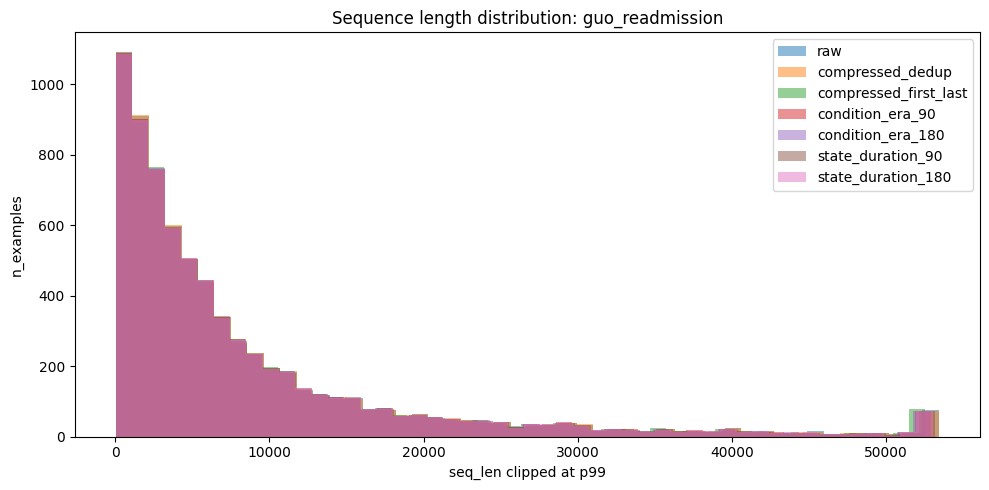

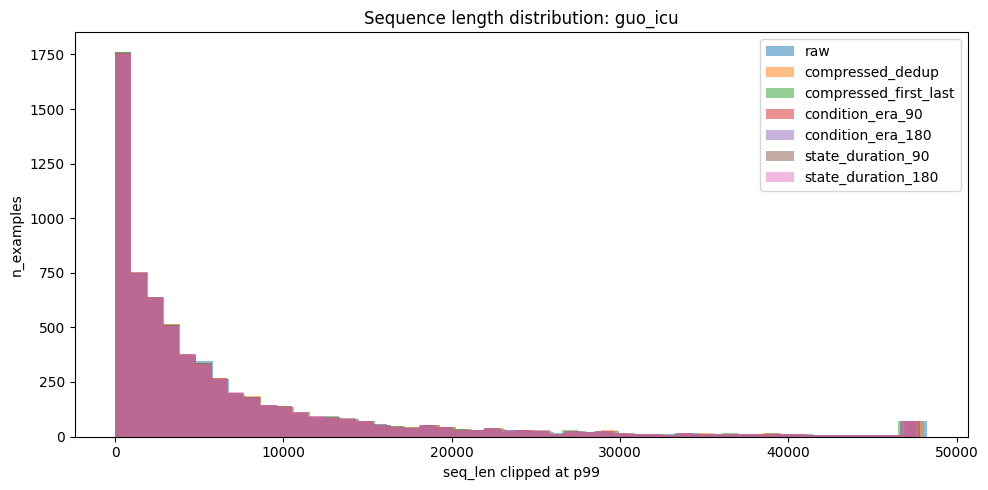

In [13]:
def plot_length_distribution(task_name: str):
    plt.figure(figsize=(10, 5))

    for version in SEQUENCE_VERSIONS:
        df = load_sequence_examples_local(task_name, version)
        clipped = df["seq_len"].clip(upper=df["seq_len"].quantile(0.99))
        plt.hist(clipped, bins=50, alpha=0.5, label=version)

    plt.title(f"Sequence length distribution: {task_name}")
    plt.xlabel("seq_len clipped at p99")
    plt.ylabel("n_examples")
    plt.legend()
    plt.tight_layout()
    plt.show()


for task_name in SELECTED_TASKS:
    plot_length_distribution(task_name)

## 6. PyTorch datasets and dataloaders

Baseline использует:

- `token_ids`;
- `log1p(days_before_prediction)`;
- `log1p(delta_days)`.

`numeric_values` сохранены, но в первом baseline не используются. Это специально: сейчас получаем рабочую точку сравнения, а missing-aware labs добавим отдельной абляцией.


In [22]:
def to_plain_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, np.ndarray):
        return x.tolist()
    if x is None:
        return []
    if isinstance(x, float) and math.isnan(x):
        return []
    return list(x) if hasattr(x, "__iter__") and not isinstance(x, str) else []


class EHRSequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, max_len: int = MAX_LEN):
        self.df = df.reset_index(drop=True)
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        token_ids = to_plain_list(row["token_ids"])
        days_before = to_plain_list(row["days_before_prediction"])
        delta_days = to_plain_list(row["delta_days"])

        if len(token_ids) == 0:
            token_ids = [UNK_ID]
            days_before = [0.0]
            delta_days = [0.0]

        # Берем последние MAX_LEN событий: для риска обычно важнее недавняя история.
        token_ids = token_ids[-self.max_len:]
        days_before = days_before[-self.max_len:]
        delta_days = delta_days[-self.max_len:]

        return {
            "row_id": int(row["row_id"]),
            "subject_id": int(row["subject_id"]),
            "tokens": token_ids,
            "days_before": days_before,
            "delta_days": delta_days,
            "label": int(row["label"]),
        }


def collate_sequence_batch(batch):
    batch_size = len(batch)
    lengths = torch.tensor([len(x["tokens"]) for x in batch], dtype=torch.long)
    max_len = int(lengths.max().item())

    tokens = torch.full((batch_size, max_len), PAD_ID, dtype=torch.long)
    time_features = torch.zeros((batch_size, max_len, 2), dtype=torch.float32)
    mask = torch.zeros((batch_size, max_len), dtype=torch.bool)
    labels = torch.tensor([x["label"] for x in batch], dtype=torch.float32)
    row_ids = torch.tensor([x["row_id"] for x in batch], dtype=torch.long)
    subject_ids = torch.tensor([x["subject_id"] for x in batch], dtype=torch.long)

    for i, item in enumerate(batch):
        l = len(item["tokens"])
        tokens[i, :l] = torch.tensor(item["tokens"], dtype=torch.long)
        time_features[i, :l, 0] = torch.log1p(torch.tensor(item["days_before"], dtype=torch.float32).clamp(min=0))
        time_features[i, :l, 1] = torch.log1p(torch.tensor(item["delta_days"], dtype=torch.float32).clamp(min=0))
        mask[i, :l] = True

    return {
        "tokens": tokens,
        "time_features": time_features,
        "mask": mask,
        "lengths": lengths,
        "labels": labels,
        "row_ids": row_ids,
        "subject_ids": subject_ids,
    }


def maybe_sample_split(df: pd.DataFrame, split: str, max_examples: int | None) -> pd.DataFrame:
    part = df[df["split"] == split].copy()
    if max_examples is not None and len(part) > max_examples:
        pos = part[part["label"] == 1]
        neg = part[part["label"] == 0]
        n_pos = min(len(pos), max(1, max_examples // 3))
        n_neg = max_examples - n_pos
        part = pd.concat([
            pos.sample(n=n_pos, random_state=RANDOM_STATE) if len(pos) > n_pos else pos,
            neg.sample(n=min(n_neg, len(neg)), random_state=RANDOM_STATE),
        ]).sample(frac=1, random_state=RANDOM_STATE)
    return part.reset_index(drop=True)


def make_loaders(df: pd.DataFrame):
    train_df = maybe_sample_split(df, "train", MAX_TRAIN_EXAMPLES)
    tuning_df = maybe_sample_split(df, "tuning", MAX_EVAL_EXAMPLES)
    heldout_df = maybe_sample_split(df, "held_out", MAX_EVAL_EXAMPLES)

    loaders = {
        "train": DataLoader(
            EHRSequenceDataset(train_df),
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            collate_fn=collate_sequence_batch,
        ),
        "tuning": DataLoader(
            EHRSequenceDataset(tuning_df),
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            collate_fn=collate_sequence_batch,
        ),
        "held_out": DataLoader(
            EHRSequenceDataset(heldout_df),
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            collate_fn=collate_sequence_batch,
        ),
    }
    return loaders, {"train": train_df, "tuning": tuning_df, "held_out": heldout_df}

## 7. Model zoo

Это не финальные архитектуры, а рабочие baselines:

- `GRU` и `LSTM` — быстрые recurrent sequence baselines;
- `RETAIN_lite` — attention baseline с проходом от более новых событий к старым;

In [23]:
class EventEmbedding(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int, dropout: float = 0.10):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_ID)
        self.time_proj = nn.Sequential(
            nn.Linear(2, emb_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim, emb_dim),
        )
        self.norm = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tokens, time_features):
        x = self.token_emb(tokens) + self.time_proj(time_features)
        return self.dropout(self.norm(x))


class RNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        rnn_type: str = "GRU",
        emb_dim: int = 64,
        hidden_dim: int = 128,
        num_layers: int = 1,
        dropout: float = 0.20,
    ):
        super().__init__()
        self.event_emb = EventEmbedding(vocab_size, emb_dim, dropout=dropout)
        rnn_cls = nn.GRU if rnn_type.upper() == "GRU" else nn.LSTM
        self.rnn = rnn_cls(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0 if num_layers == 1 else dropout,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, tokens, time_features, mask, lengths):
        x = self.event_emb(tokens, time_features)
        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, h = self.rnn(packed)
        if isinstance(h, tuple):
            h = h[0]
        last_h = h[-1]
        return self.head(last_h).squeeze(-1)


def reverse_by_lengths(x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
    out = x.clone()
    for i, l in enumerate(lengths.tolist()):
        out[i, :l] = x[i, :l].flip(0)
    return out


class RetainLiteClassifier(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int = 64, hidden_dim: int = 128, dropout: float = 0.20):
        super().__init__()
        self.event_emb = EventEmbedding(vocab_size, emb_dim, dropout=dropout)
        self.alpha_gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.beta_gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.alpha_fc = nn.Linear(hidden_dim, 1)
        self.beta_fc = nn.Linear(hidden_dim, emb_dim)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(emb_dim, 1),
        )

    def forward(self, tokens, time_features, mask, lengths):
        x = self.event_emb(tokens, time_features)
        x_rev = reverse_by_lengths(x, lengths)

        alpha_h, _ = self.alpha_gru(x_rev)
        beta_h, _ = self.beta_gru(x_rev)

        alpha_logits = self.alpha_fc(alpha_h).squeeze(-1)
        alpha_logits = alpha_logits.masked_fill(~mask, -1e9)
        alpha = torch.softmax(alpha_logits, dim=1)

        beta = torch.tanh(self.beta_fc(beta_h))
        context = torch.sum(alpha.unsqueeze(-1) * beta * x_rev, dim=1)
        return self.head(context).squeeze(-1)


def make_model_zoo(vocab_size: int) -> dict[str, nn.Module]:
    return {
        "GRU_1L": RNNClassifier(
            vocab_size=vocab_size,
            rnn_type="GRU",
            num_layers=1,
        ),
        "GRU_2L": RNNClassifier(
            vocab_size=vocab_size,
            rnn_type="GRU",
            num_layers=2,
        ),
        "LSTM_1L": RNNClassifier(
            vocab_size=vocab_size,
            rnn_type="LSTM",
            num_layers=1,
        ),
        "LSTM_2L": RNNClassifier(
            vocab_size=vocab_size,
            rnn_type="LSTM",
            num_layers=2,
        ),
        "RETAIN_lite": RetainLiteClassifier(vocab_size=vocab_size),
    }

## 8. Training and evaluation utilities

Основная оценка не использует fixed threshold. Модель оценивается как risk ranking model: AUROC, AUPRC, Brier/LogLoss и top-k risk stratification.


Сохраняем две версии вероятностей:

- `raw` — sigmoid от logits модели;
- `platt` — Platt scaling, обученный на `tuning` logits.


In [24]:
def move_batch_to_device(batch, device):
    return {
        k: (v.to(device) if torch.is_tensor(v) else v)
        for k, v in batch.items()
    }


def predict_loader(model: nn.Module, loader: DataLoader, device=DEVICE) -> dict[str, np.ndarray]:
    model.eval()
    logits_all, y_all, row_ids_all, subject_ids_all = [], [], [], []

    with torch.no_grad():
        for batch in loader:
            batch = move_batch_to_device(batch, device)
            logits = model(
                batch["tokens"],
                batch["time_features"],
                batch["mask"],
                batch["lengths"],
            )
            logits_all.append(logits.detach().cpu().numpy())
            y_all.append(batch["labels"].detach().cpu().numpy())
            row_ids_all.append(batch["row_ids"].detach().cpu().numpy())
            subject_ids_all.append(batch["subject_ids"].detach().cpu().numpy())

    logits = np.concatenate(logits_all)
    y_true = np.concatenate(y_all).astype(int)
    probs = 1 / (1 + np.exp(-np.clip(logits, -30, 30)))

    return {
        "row_id": np.concatenate(row_ids_all),
        "subject_id": np.concatenate(subject_ids_all),
        "y_true": y_true,
        "logits": logits,
        "probs": probs,
    }


def choose_threshold_on_tuning(y_true, y_prob) -> float:
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5

    f1 = 2 * precision[:-1] * recall[:-1] / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
    best_idx = int(np.nanargmax(f1))
    return float(thresholds[best_idx])


def compute_binary_metrics(y_true, y_prob, threshold: float) -> dict:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "auroc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "auprc": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "brier": brier_score_loss(y_true, y_prob),
        "logloss": log_loss(y_true, np.clip(y_prob, 1e-6, 1 - 1e-6), labels=[0, 1]),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "predicted_positive_rate": float(y_pred.mean()),
        "threshold": float(threshold),
    }
    return out

def compute_topk_metrics(y_true, y_prob, top_fracs=(0.01, 0.05, 0.10, 0.20)) -> pd.DataFrame:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    n = len(y_true)
    n_pos = int(y_true.sum())
    base_rate = float(y_true.mean()) if n > 0 else np.nan

    order = np.argsort(-y_prob)

    rows = []

    for frac in top_fracs:
        k = max(1, int(np.ceil(n * frac)))
        idx = order[:k]

        selected_events = int(y_true[idx].sum())
        selected_event_rate = selected_events / k
        lift = selected_event_rate / base_rate if base_rate > 0 else np.nan
        event_capture = selected_events / n_pos if n_pos > 0 else np.nan

        rows.append({
            "top_frac": frac,
            "top_k": k,
            "events_in_top_k": selected_events,
            "top_k_event_rate": selected_event_rate,
            "top_k_lift": lift,
            "event_capture": event_capture,
            "base_event_rate": base_rate,
            "n": n,
            "n_positive": n_pos,
        })

    return pd.DataFrame(rows)

def compute_ranking_metrics(y_true, y_prob) -> dict:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    out = {
        "auroc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "auprc": average_precision_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan,
        "brier": brier_score_loss(y_true, y_prob),
        "logloss": log_loss(
            y_true,
            np.clip(y_prob, 1e-6, 1 - 1e-6),
            labels=[0, 1],
        ),
        "event_rate": float(y_true.mean()),
        "n": int(len(y_true)),
        "n_positive": int(y_true.sum()),
    }

    return out

def fit_platt_scaler(tuning_logits: np.ndarray, y_tuning: np.ndarray):
    if len(np.unique(y_tuning)) < 2:
        return None
    clf = LogisticRegression(solver="lbfgs")
    clf.fit(tuning_logits.reshape(-1, 1), y_tuning.astype(int))
    return clf


def apply_platt(platt_model, logits: np.ndarray) -> np.ndarray:
    if platt_model is None:
        return 1 / (1 + np.exp(-np.clip(logits, -30, 30)))
    return platt_model.predict_proba(logits.reshape(-1, 1))[:, 1]

In [25]:
def train_sequence_model(
    model: nn.Module,
    loaders: dict[str, DataLoader],
    device=DEVICE,
    n_epochs: int = N_EPOCHS,
    patience: int = PATIENCE,
) -> tuple[nn.Module, pd.DataFrame]:
    model = model.to(device)

    train_labels = []
    for batch in loaders["train"]:
        train_labels.append(batch["labels"].numpy())
    y_train = np.concatenate(train_labels).astype(int)

    n_pos = max(1, int(y_train.sum()))
    n_neg = max(1, int(len(y_train) - y_train.sum()))
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    best_state = deepcopy(model.state_dict())
    best_tuning_auprc = -np.inf
    best_epoch = -1
    bad_epochs = 0
    history_rows = []

    for epoch in range(1, n_epochs + 1):
        model.train()
        losses = []

        for batch in loaders["train"]:
            batch = move_batch_to_device(batch, device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(
                batch["tokens"],
                batch["time_features"],
                batch["mask"],
                batch["lengths"],
            )
            loss = criterion(logits, batch["labels"])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            losses.append(float(loss.detach().cpu()))

        tuning_pred = predict_loader(model, loaders["tuning"], device=device)
        tuning_auprc = average_precision_score(tuning_pred["y_true"], tuning_pred["probs"])
        tuning_auroc = roc_auc_score(tuning_pred["y_true"], tuning_pred["probs"]) if len(np.unique(tuning_pred["y_true"])) > 1 else np.nan

        history_rows.append({
            "epoch": epoch,
            "train_loss": float(np.mean(losses)),
            "tuning_auprc": float(tuning_auprc),
            "tuning_auroc": float(tuning_auroc),
        })

        print(f"epoch={epoch:02d} loss={np.mean(losses):.4f} tuning_auprc={tuning_auprc:.4f} tuning_auroc={tuning_auroc:.4f}")

        if tuning_auprc > best_tuning_auprc + 1e-5:
            best_tuning_auprc = tuning_auprc
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping at epoch={epoch}; best_epoch={best_epoch}")
                break

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history_rows)
    history_df["best_epoch"] = best_epoch
    return model, history_df


def evaluate_model_with_calibration(task_name: str, version: str, model_name: str, model: nn.Module, loaders: dict[str, DataLoader]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    tuning_pred = predict_loader(model, loaders["tuning"])
    heldout_pred = predict_loader(model, loaders["held_out"])

    rows = []
    prediction_frames = []
    topk_frames = []

    platt = fit_platt_scaler(tuning_pred["logits"], tuning_pred["y_true"])

    for calibration in ["raw", "platt"]:
        if calibration == "raw":
            p_tuning = tuning_pred["probs"]
            p_heldout = heldout_pred["probs"]
        else:
            p_tuning = apply_platt(platt, tuning_pred["logits"])
            p_heldout = apply_platt(platt, heldout_pred["logits"])

        # threshold = choose_threshold_on_tuning(tuning_pred["y_true"], p_tuning)
        # tuning_metrics = compute_binary_metrics(tuning_pred["y_true"], p_tuning, threshold)
        # heldout_metrics = compute_binary_metrics(heldout_pred["y_true"], p_heldout, threshold)

        tuning_metrics = compute_ranking_metrics(
            tuning_pred["y_true"],
            p_tuning,
        )

        heldout_metrics = compute_ranking_metrics(
            heldout_pred["y_true"],
            p_heldout,
        )

        row = {
            "task": task_name,
            "version": version,
            "model": model_name,
            "calibration": calibration,
            "n_tuning": len(tuning_pred["y_true"]),
            "n_heldout": len(heldout_pred["y_true"]),
            "n_positive_heldout": int(heldout_pred["y_true"].sum()),
            "event_rate_heldout": float(heldout_pred["y_true"].mean()),
            # "threshold_selected_on_tuning": threshold,
        }
        row.update({f"tuning_{k}": v for k, v in tuning_metrics.items()})
        row.update({f"heldout_{k}": v for k, v in heldout_metrics.items()})
        rows.append(row)

        prediction_frames.append(pd.DataFrame({
            "task": task_name,
            "version": version,
            "model": model_name,
            "calibration": calibration,
            "row_id": heldout_pred["row_id"],
            "subject_id": heldout_pred["subject_id"],
            "y_true": heldout_pred["y_true"],
            "logit": heldout_pred["logits"],
            "risk": p_heldout,
        }))

        topk_df = compute_topk_metrics(
            heldout_pred["y_true"],
            p_heldout,
            top_fracs=(0.01, 0.05, 0.10, 0.20),
        )

        topk_df.insert(0, "task", task_name)
        topk_df.insert(1, "version", version)
        topk_df.insert(2, "model", model_name)
        topk_df.insert(3, "calibration", calibration)

        topk_frames.append(topk_df)

    return (
        pd.DataFrame(rows),
        pd.concat(prediction_frames, ignore_index=True),
        pd.concat(topk_frames, ignore_index=True),
    )

## 9. Run sequence baselines

Запускаем все модели для `raw` и `compressed` версий обеих задач.

In [26]:
def load_vocab(task_name: str, version: str) -> dict[str, int]:
    vocab_path = SEQUENCE_DATA_DIR / task_name / version / "vocab.json"
    with open(vocab_path, "r", encoding="utf-8") as f:
        return json.load(f)


def run_one_experiment(task_name: str, version: str, model_name: str):
    print("\n" + "=" * 100)
    print(f"Experiment: {task_name} | {version} | {model_name}")

    df = load_sequence_examples(task_name, version)
    vocab = load_vocab(task_name, version)
    vocab_size = len(vocab)

    loaders, split_dfs = make_loaders(df)
    model = make_model_zoo(vocab_size)[model_name]

    model, history_df = train_sequence_model(model, loaders)
    result_df, pred_df, topk_df = evaluate_model_with_calibration(task_name, version, model_name, model, loaders)

    exp_name = f"{task_name}__{version}__{model_name}"
    history_path = RESULTS_DIR / f"{exp_name}__history.csv"
    pred_path = RESULTS_DIR / f"{exp_name}__heldout_predictions.csv"
    topk_path = RESULTS_DIR / f"{exp_name}__topk.csv"

    topk_df.to_csv(topk_path, index=False)
    history_df.to_csv(history_path, index=False)
    pred_df.to_csv(pred_path, index=False)

    if SAVE_MODEL_CHECKPOINTS:
        ckpt_path = CHECKPOINT_DIR / f"{exp_name}.pt"
        torch.save({
            "task": task_name,
            "version": version,
            "model_name": model_name,
            "vocab_size": vocab_size,
            "max_len": MAX_LEN,
            "state_dict": model.state_dict(),
        }, ckpt_path)
        print("Saved checkpoint:", ckpt_path)

    print("Saved history:", history_path)
    print("Saved predictions:", pred_path)
    print("Saved top-k metrics:", topk_path)

    display(result_df[[
            "task",
            "version",
            "model",
            "calibration",
            "heldout_auroc",
            "heldout_auprc",
            "heldout_brier",
            "heldout_logloss",
            "event_rate_heldout",
        ]])
    
    display(topk_df[[
        "task",
        "version",
        "model",
        "calibration",
        "top_frac",
        "top_k",
        "events_in_top_k",
        "top_k_event_rate",
        "top_k_lift",
        "event_capture",
    ]])

    return result_df, pred_df, history_df

In [27]:
all_result_tables = []
all_prediction_tables = []
all_history_tables = []

for task_name in SELECTED_TASKS:
    for version in SEQUENCE_VERSIONS:
        for model_name in RUN_MODEL_NAMES:
            result_df, pred_df, history_df = run_one_experiment(task_name, version, model_name)
            all_result_tables.append(result_df)
            all_prediction_tables.append(pred_df)
            history_df = history_df.copy()
            history_df["task"] = task_name
            history_df["version"] = version
            history_df["model"] = model_name
            all_history_tables.append(history_df)

sequence_results_df = pd.concat(all_result_tables, ignore_index=True)
sequence_predictions_df = pd.concat(all_prediction_tables, ignore_index=True)
sequence_history_df = pd.concat(all_history_tables, ignore_index=True)

results_path = RESULTS_DIR / "sequence_baseline_results.csv"
predictions_path = RESULTS_DIR / "sequence_baseline_heldout_predictions.csv"
history_path = RESULTS_DIR / "sequence_baseline_training_history.csv"

sequence_results_df.to_csv(results_path, index=False)
sequence_predictions_df.to_csv(predictions_path, index=False)
sequence_history_df.to_csv(history_path, index=False)

print("Saved:", results_path)
print("Saved:", predictions_path)
print("Saved:", history_path)

display(sequence_results_df.sort_values(["task", "version", "heldout_auprc"], ascending=[True, True, False]))


Experiment: guo_readmission | raw | GRU_1L
epoch=01 loss=1.1528 tuning_auprc=0.2677 tuning_auroc=0.6580
epoch=02 loss=1.0432 tuning_auprc=0.2896 tuning_auroc=0.6963
epoch=03 loss=0.9329 tuning_auprc=0.2987 tuning_auroc=0.7066
epoch=04 loss=0.8572 tuning_auprc=0.3004 tuning_auroc=0.7006
epoch=05 loss=0.8056 tuning_auprc=0.3264 tuning_auroc=0.7208
epoch=06 loss=0.7193 tuning_auprc=0.3222 tuning_auroc=0.7157
epoch=07 loss=0.6644 tuning_auprc=0.3409 tuning_auroc=0.7200
epoch=08 loss=0.6022 tuning_auprc=0.3049 tuning_auroc=0.6897
epoch=09 loss=0.5365 tuning_auprc=0.3112 tuning_auroc=0.6984
epoch=10 loss=0.4842 tuning_auprc=0.3039 tuning_auroc=0.6977
Early stopping at epoch=10; best_epoch=7
Saved checkpoint:2026-06-17 14:31:09,071 - clearml.storage - INFO - Starting upload: /var/folders/v5/_5rgnv1s17zbz3kxbhgwr18r0000gn/T/.clearml.upload_model_7la8ym5h.tmp => api.blackhole2.ai.innopolis.university:443/pershin-medailab/pershin-medailab/EHR_Risk_Profiling/EHRSHOT/sequence_baseline_notebook_v1

,task,version,model,calibration,heldout_auroc,heldout_auprc,heldout_brier,heldout_logloss,event_rate_heldout
0,guo_readmission,raw,GRU_1L,raw,0.73108,0.288969,0.162927,0.515681,0.118776
1,guo_readmission,raw,GRU_1L,platt,0.73108,0.288969,0.095696,0.327282,0.118776


,task,version,model,calibration,top_frac,top_k,events_in_top_k,top_k_event_rate,top_k_lift,event_capture
0,guo_readmission,raw,GRU_1L,raw,0.01,22,11,0.500000,4.209615,0.042308
1,guo_readmission,raw,GRU_1L,raw,0.05,110,45,0.409091,3.444231,0.173077
2,guo_readmission,raw,GRU_1L,raw,0.10,219,72,0.328767,2.767966,0.276923
3,guo_readmission,raw,GRU_1L,raw,0.20,438,122,0.278539,2.345083,0.469231
4,guo_readmission,raw,GRU_1L,platt,0.01,22,11,0.500000,4.209615,0.042308
5,guo_readmission,raw,GRU_1L,platt,0.05,110,45,0.409091,3.444231,0.173077
6,guo_readmission,raw,GRU_1L,platt,0.10,219,72,0.328767,2.767966,0.276923
7,guo_readmission,raw,GRU_1L,platt,0.20,438,122,0.278539,2.345083,0.469231



Experiment: guo_readmission | raw | GRU_2L
2026-06-17 14:31:09,458 - clearml.storage - INFO - Uploading: 5.15MB from /var/folders/v5/_5rgnv1s17zbz3kxbhgwr18r0000gn/T/.clearml.upload_model_7la8ym5h.tmp


█████████████████████████████████ 100% | 5.15/5.15 MB [00:01<00:00,  2.79MB/s]: 

...

                                             0% | 0.00/5.6 MB [00:00<?, ?MB/s]: 

Saved: ehrshot_sequence_results/sequence_baseline_results.csv
Saved: ehrshot_sequence_results/sequence_baseline_heldout_predictions.csv
Saved: ehrshot_sequence_results/sequence_baseline_training_history.csv


,task,version,model,calibration,n_tuning,n_heldout,n_positive_heldout,event_rate_heldout,tuning_auroc,tuning_auprc,...,tuning_event_rate,tuning_n,tuning_n_positive,heldout_auroc,heldout_auprc,heldout_brier,heldout_logloss,heldout_event_rate,heldout_n,heldout_n_positive
84,guo_icu,compressed_condition_era,LSTM_1L,raw,2052,2037,85,0.041728,0.751475,0.202893,...,0.044834,2052,92,0.722191,0.184673,0.235806,0.709464,0.041728,2037,85
85,guo_icu,compressed_condition_era,LSTM_1L,platt,2052,2037,85,0.041728,0.751475,0.202893,...,0.044834,2052,92,0.722191,0.184673,0.037907,0.157627,0.041728,2037,85
80,guo_icu,compressed_condition_era,GRU_1L,raw,2052,2037,85,0.041728,0.782620,0.202428,...,0.044834,2052,92,0.717756,0.143717,0.077577,0.284825,0.041728,2037,85
81,guo_icu,compressed_condition_era,GRU_1L,platt,2052,2037,85,0.041728,0.782620,0.202428,...,0.044834,2052,92,0.717756,0.143717,0.039044,0.162004,0.041728,2037,85
82,guo_icu,compressed_condition_era,GRU_2L,raw,2052,2037,85,0.041728,0.740301,0.239281,...,0.044834,2052,92,0.676935,0.141355,0.123032,0.409626,0.041728,2037,85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3,guo_readmission,raw,GRU_2L,platt,2206,2189,260,0.118776,0.723731,0.309300,...,0.127380,2206,281,0.722234,0.300099,0.095148,0.327441,0.118776,2189,260
0,guo_readmission,raw,GRU_1L,raw,2206,2189,260,0.118776,0.720000,0.340944,...,0.127380,2206,281,0.731080,0.288969,0.162927,0.515681,0.118776,2189,260
1,guo_readmission,raw,GRU_1L,platt,2206,2189,260,0.118776,0.720000,0.340944,...,0.127380,2206,281,0.731080,0.288969,0.095696,0.327282,0.118776,2189,260
6,guo_readmission,raw,LSTM_2L,raw,2206,2189,260,0.118776,0.718719,0.302122,...,0.127380,2206,281,0.706821,0.270742,0.211146,0.620087,0.118776,2189,260


██████████████████████████████████ 100% | 5.60/5.6 MB [00:01<00:00,  3.34MB/s]: 

2026-06-17 18:30:17,616 - clearml.Task - INFO - Completed model upload to s3://api.blackhole2.ai.innopolis.university:443/pershin-medailab/pershin-medailab/EHR_Risk_Profiling/EHRSHOT/sequence_baseline_notebook_v1.84e2aef056324facb0d0dcc12baa9562/models/guo_icu__compressed_hybrid__RETAIN_lite.pt


`mean_compression_tokens` считает только добавленные служебные compression tokens. Для `dedup` это значение может быть 0, потому что dedup удаляет повторы без добавления новых synthetic tokens.

## 10. Compare models

Основная оценка рассматривает модели как risk ranking models, а не как binary classifiers с фиксированным threshold.

Главные метрики:

* `heldout_auprc` — основная ranking-метрика при дисбалансе классов;
* `heldout_auroc` — общее качество ранжирования positive examples выше negative examples;
* `heldout_brier` — качество вероятностной оценки риска, меньше лучше;
* `heldout_logloss` — дополнительная метрика качества вероятностей, меньше лучше;
* top-k risk stratification — доля реальных событий среди пациентов с наибольшим predicted risk.

Platt calibration обучается на `tuning` split и применяется к `held_out`. Она не меняет порядок пациентов и поэтому почти не влияет на AUROC/AUPRC, но улучшает Brier score и LogLoss.

In [28]:
metric_cols = [
    "task",
    "version",
    "model",
    "calibration",
    "n_tuning",
    "n_heldout",
    "n_positive_heldout",
    "event_rate_heldout",
    "heldout_auroc",
    "heldout_auprc",
    "heldout_brier",
    "heldout_logloss",
]

comparison_df = (
    sequence_results_df[metric_cols]
    .sort_values(["task", "version", "heldout_auprc"], ascending=[True, True, False])
    .reset_index(drop=True)
)

display(comparison_df)

comparison_path = RESULTS_DIR / "sequence_baseline_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

,task,version,model,calibration,n_tuning,n_heldout,n_positive_heldout,event_rate_heldout,heldout_auroc,heldout_auprc,heldout_brier,heldout_logloss
0,guo_icu,compressed_condition_era,LSTM_1L,raw,2052,2037,85,0.041728,0.722191,0.184673,0.235806,0.709464
1,guo_icu,compressed_condition_era,LSTM_1L,platt,2052,2037,85,0.041728,0.722191,0.184673,0.037907,0.157627
2,guo_icu,compressed_condition_era,GRU_1L,raw,2052,2037,85,0.041728,0.717756,0.143717,0.077577,0.284825
3,guo_icu,compressed_condition_era,GRU_1L,platt,2052,2037,85,0.041728,0.717756,0.143717,0.039044,0.162004
4,guo_icu,compressed_condition_era,GRU_2L,raw,2052,2037,85,0.041728,0.676935,0.141355,0.123032,0.409626
...,...,...,...,...,...,...,...,...,...,...,...,...
95,guo_readmission,raw,GRU_2L,platt,2206,2189,260,0.118776,0.722234,0.300099,0.095148,0.327441
96,guo_readmission,raw,GRU_1L,raw,2206,2189,260,0.118776,0.731080,0.288969,0.162927,0.515681
97,guo_readmission,raw,GRU_1L,platt,2206,2189,260,0.118776,0.731080,0.288969,0.095696,0.327282
98,guo_readmission,raw,LSTM_2L,raw,2206,2189,260,0.118776,0.706821,0.270742,0.211146,0.620087


Saved: ehrshot_sequence_results/sequence_baseline_comparison.csv


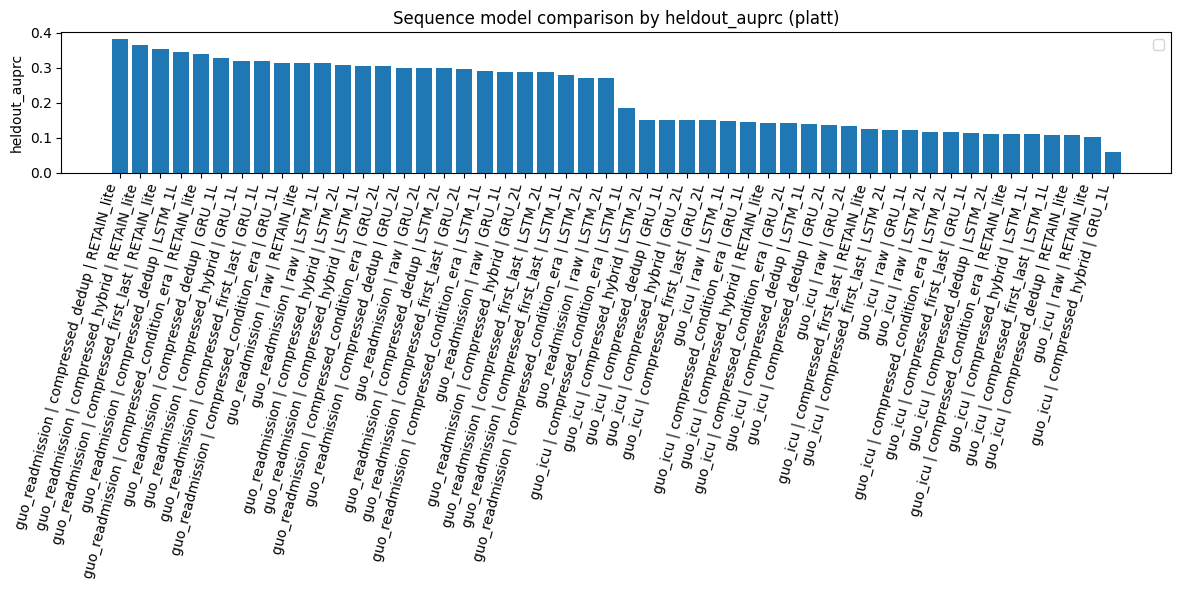

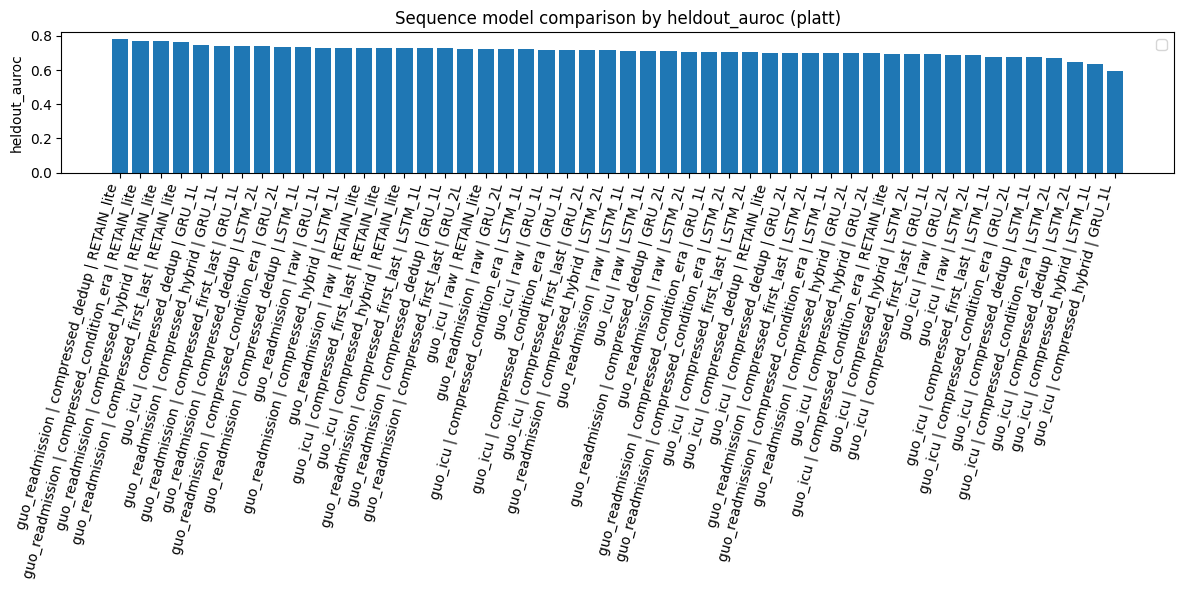

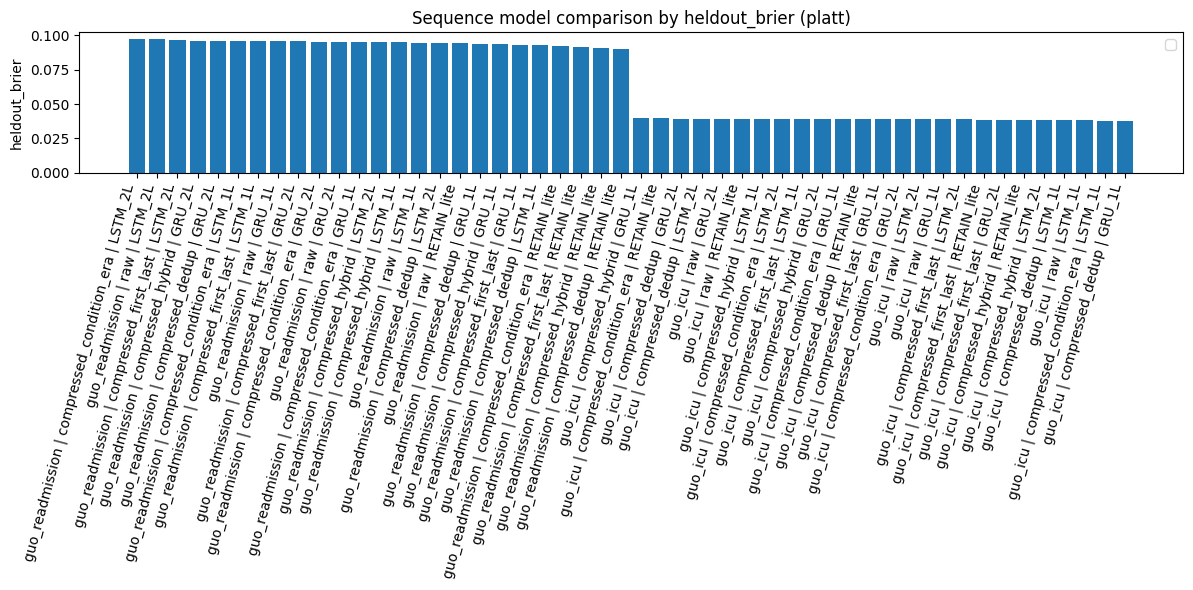

In [30]:
def plot_metric_comparison(results_df: pd.DataFrame, metric: str, calibration: str = "platt"):
    plot_df = results_df[results_df["calibration"] == calibration].copy()
    plot_df["label"] = plot_df["task"] + " | " + plot_df["version"] + " | " + plot_df["model"]
    plot_df = plot_df.sort_values(metric, ascending=False)

    plt.figure(figsize=(12, 6))
    plt.bar(plot_df["label"], plot_df[metric])
    plt.xticks(rotation=75, ha="right")
    plt.ylabel(metric)
    plt.title(f"Sequence model comparison by {metric} ({calibration})")
    plt.tight_layout()
    plt.show()


for metric in ["heldout_auprc", "heldout_auroc", "heldout_brier"]:
    plot_metric_comparison(sequence_results_df, metric, calibration="platt")


## 11. Raw vs compressed ablation

Основной вопрос этого ноутбука:

> Сжимает ли `compressed` последовательность без явного провала качества относительно `raw`?

Смотрим `delta = compressed - raw` по одинаковой задаче, модели и calibration.


In [31]:
raw_vs_compressed = sequence_results_df.pivot_table(
    index=["task", "model", "calibration"],
    columns="version",
    values=["heldout_auroc", "heldout_auprc", "heldout_brier", "heldout_logloss"],
    aggfunc="first",
)

raw_vs_compressed.columns = [
    f"{metric}__{version}"
    for metric, version in raw_vs_compressed.columns
]

raw_vs_compressed = raw_vs_compressed.reset_index()

compression_versions = [v for v in SEQUENCE_VERSIONS if v != "raw"]

for metric in ["heldout_auroc", "heldout_auprc", "heldout_brier", "heldout_logloss"]:
    raw_col = f"{metric}__raw"

    for version in compression_versions:
        comp_col = f"{metric}__{version}"

        if raw_col in raw_vs_compressed.columns and comp_col in raw_vs_compressed.columns:
            raw_vs_compressed[f"delta_{metric}__{version}_minus_raw"] = (
                raw_vs_compressed[comp_col] - raw_vs_compressed[raw_col]
            )

raw_vs_compression_path = RESULTS_DIR / "sequence_raw_vs_compression_ablation.csv"
raw_vs_compressed.to_csv(raw_vs_compression_path, index=False)

print("Saved:", raw_vs_compression_path)
display(raw_vs_compressed.sort_values(["task", "model", "calibration"]))

Saved: ehrshot_sequence_results/sequence_raw_vs_compression_ablation.csv


,task,model,calibration,heldout_auprc__compressed_condition_era,heldout_auprc__compressed_dedup,heldout_auprc__compressed_first_last,heldout_auprc__compressed_hybrid,heldout_auprc__raw,heldout_auroc__compressed_condition_era,heldout_auroc__compressed_dedup,...,delta_heldout_auprc__compressed_condition_era_minus_raw,delta_heldout_auprc__compressed_hybrid_minus_raw,delta_heldout_brier__compressed_dedup_minus_raw,delta_heldout_brier__compressed_first_last_minus_raw,delta_heldout_brier__compressed_condition_era_minus_raw,delta_heldout_brier__compressed_hybrid_minus_raw,delta_heldout_logloss__compressed_dedup_minus_raw,delta_heldout_logloss__compressed_first_last_minus_raw,delta_heldout_logloss__compressed_condition_era_minus_raw,delta_heldout_logloss__compressed_hybrid_minus_raw
0,guo_icu,GRU_1L,platt,0.143717,0.151499,0.114557,0.057995,0.121169,0.717756,0.745474,...,0.022549,-0.063174,-0.001047,0.000087,0.000113,0.000893,-0.006279,0.001581,0.000113,0.009484
1,guo_icu,GRU_1L,raw,0.143717,0.151499,0.114557,0.057995,0.121169,0.717756,0.745474,...,0.022549,-0.063174,-0.016349,-0.033361,-0.045975,0.061170,-0.047195,-0.074108,-0.123962,0.150077
2,guo_icu,GRU_2L,platt,0.141355,0.135185,0.149425,0.151230,0.132453,0.676935,0.701326,...,0.008902,0.018777,0.000024,-0.000764,-0.000256,-0.000190,0.000165,-0.003949,0.000498,-0.000929
3,guo_icu,GRU_2L,raw,0.141355,0.135185,0.149425,0.151230,0.132453,0.676935,0.701326,...,0.008902,0.018777,0.072303,0.121735,0.075316,0.005027,0.274435,0.362907,0.220987,0.017270
4,guo_icu,LSTM_1L,platt,0.184673,0.138768,0.107393,0.109903,0.146446,0.722191,0.675476,...,0.038227,-0.036543,0.000182,0.001064,-0.000141,0.001083,0.004540,0.007309,0.000169,0.008535
5,guo_icu,LSTM_1L,raw,0.184673,0.138768,0.107393,0.109903,0.146446,0.722191,0.675476,...,0.038227,-0.036543,0.031779,0.003365,0.136873,-0.036391,0.075520,-0.004729,0.352378,-0.113966
6,guo_icu,LSTM_2L,platt,0.115139,0.111815,0.123167,0.152087,0.116782,0.668316,0.645745,...,-0.001643,0.035305,0.000294,-0.000158,0.000139,-0.000509,0.003404,-0.001175,0.001618,-0.001239
7,guo_icu,LSTM_2L,raw,0.115139,0.111815,0.123167,0.152087,0.116782,0.668316,0.645745,...,-0.001643,0.035305,0.024059,0.041969,0.032528,0.088480,0.053955,0.089040,0.078335,0.251983
8,guo_icu,RETAIN_lite,platt,0.111322,0.106461,0.125002,0.143408,0.102266,0.694214,0.701953,...,0.009056,0.041142,-0.000203,-0.000544,0.000335,-0.000750,0.000767,-0.003362,0.003930,-0.002767
9,guo_icu,RETAIN_lite,raw,0.111322,0.106461,0.125002,0.143408,0.102266,0.694214,0.701953,...,0.009056,0.041142,0.004717,0.009405,-0.063339,0.023498,0.013110,0.031782,-0.154521,0.069648


## 12. Top-k risk stratification

Для медицинского risk profiling важно не только F1 по threshold, но и вопрос:

> Если взять top 1%, 5%, 10%, 20% examples по predicted risk, сколько там реальных событий?

Это напрямую связано с risk-based routing.


In [32]:
TOPK_FRACTIONS = [0.01, 0.05, 0.10, 0.20]


def top_k_risk_table(pred_df: pd.DataFrame, topk_fractions: list[float] = TOPK_FRACTIONS) -> pd.DataFrame:
    rows = []

    for (task, version, model, calibration), group in pred_df.groupby(["task", "version", "model", "calibration"]):
        df = group.sort_values("risk", ascending=False).reset_index(drop=True)
        total_examples = len(df)
        total_patients = df["subject_id"].nunique()
        total_events = int(df["y_true"].sum())
        base_event_rate = float(df["y_true"].mean())

        for frac in topk_fractions:
            n_selected = max(1, int(np.ceil(total_examples * frac)))
            top = df.head(n_selected)
            n_events = int(top["y_true"].sum())
            event_rate = float(top["y_true"].mean())

            rows.append({
                "task": task,
                "version": version,
                "model": model,
                "calibration": calibration,
                "top_k_percent": int(frac * 100),
                "n_selected_examples": n_selected,
                "n_selected_patients": top["subject_id"].nunique(),
                "n_events_in_top_k": n_events,
                "total_events_heldout": total_events,
                "event_rate_in_top_k": event_rate,
                "base_event_rate": base_event_rate,
                "lift_vs_base_rate": event_rate / base_event_rate if base_event_rate > 0 else np.nan,
                "events_covered_share": n_events / total_events if total_events > 0 else np.nan,
                "examples_covered_share": n_selected / total_examples,
                "patients_covered_share": top["subject_id"].nunique() / total_patients if total_patients > 0 else np.nan,
                "min_risk_in_top_k": float(top["risk"].min()),
                "max_risk_in_top_k": float(top["risk"].max()),
                "mean_risk_in_top_k": float(top["risk"].mean()),
            })

    return pd.DataFrame(rows)


topk_results_df = top_k_risk_table(sequence_predictions_df)
topk_path = RESULTS_DIR / "sequence_topk_risk_stratification.csv"
topk_results_df.to_csv(topk_path, index=False)

print("Saved:", topk_path)
display(topk_results_df.sort_values(["task", "version", "model", "calibration", "top_k_percent"]))


Saved: ehrshot_sequence_results/sequence_topk_risk_stratification.csv


,task,version,model,calibration,top_k_percent,n_selected_examples,n_selected_patients,n_events_in_top_k,total_events_heldout,event_rate_in_top_k,base_event_rate,lift_vs_base_rate,events_covered_share,examples_covered_share,patients_covered_share,min_risk_in_top_k,max_risk_in_top_k,mean_risk_in_top_k
0,guo_icu,compressed_condition_era,GRU_1L,platt,1,21,19,7,85,0.333333,0.041728,7.988235,0.082353,0.010309,0.016464,0.383406,0.549789,0.448781
1,guo_icu,compressed_condition_era,GRU_1L,platt,5,102,86,17,85,0.166667,0.041728,3.994118,0.200000,0.050074,0.074523,0.157795,0.549789,0.297332
2,guo_icu,compressed_condition_era,GRU_1L,platt,10,204,163,28,85,0.137255,0.041728,3.289273,0.329412,0.100147,0.141248,0.062333,0.549789,0.197407
3,guo_icu,compressed_condition_era,GRU_1L,platt,20,408,314,41,85,0.100490,0.041728,2.408218,0.482353,0.200295,0.272097,0.037948,0.549789,0.121972
4,guo_icu,compressed_condition_era,GRU_1L,raw,1,21,19,7,85,0.333333,0.041728,7.988235,0.082353,0.010309,0.016464,0.971180,0.992094,0.981359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,guo_readmission,raw,RETAIN_lite,platt,20,438,245,126,260,0.287671,0.118776,2.421970,0.484615,0.200091,0.205882,0.192116,0.574693,0.287083
396,guo_readmission,raw,RETAIN_lite,raw,1,22,15,12,260,0.545455,0.118776,4.592308,0.046154,0.010050,0.012605,0.940021,0.983389,0.962341
397,guo_readmission,raw,RETAIN_lite,raw,5,110,68,49,260,0.445455,0.118776,3.750385,0.188462,0.050251,0.057143,0.810258,0.983389,0.891140
398,guo_readmission,raw,RETAIN_lite,raw,10,219,134,82,260,0.374429,0.118776,3.152406,0.315385,0.100046,0.112605,0.680520,0.983389,0.820320


## 13. Bootstrap confidence intervals

Добавляем простой bootstrap на held-out prediction examples для лучших конфигураций.

По умолчанию берем лучшую `platt`-калиброванную модель по AUPRC внутри каждой пары `task × version`.


In [33]:
N_BOOTSTRAP = 1000


def bootstrap_metric_ci(y_true, y_prob, metric_fn, n_bootstrap: int = N_BOOTSTRAP, ci: float = 0.95, random_state: int = RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    n = len(y_true)
    values = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        y_b = y_true[idx]
        p_b = y_prob[idx]
        try:
            values.append(metric_fn(y_b, p_b))
        except Exception:
            values.append(np.nan)

    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    alpha = 1 - ci

    return {
        "mean": float(np.mean(values)),
        "ci_low": float(np.quantile(values, alpha / 2)),
        "ci_high": float(np.quantile(values, 1 - alpha / 2)),
        "n_bootstrap_valid": int(len(values)),
    }


def auroc_metric(y, p):
    return roc_auc_score(y, p) if len(np.unique(y)) > 1 else np.nan


def auprc_metric(y, p):
    return average_precision_score(y, p) if len(np.unique(y)) > 1 else np.nan


def topk_precision_metric(k_fraction: float):
    def metric(y, p):
        n_top = max(1, int(np.ceil(len(y) * k_fraction)))
        order = np.argsort(-p)
        return float(np.asarray(y)[order[:n_top]].mean())
    return metric


best_platt = (
    sequence_results_df[sequence_results_df["calibration"] == "platt"]
    .sort_values(["task", "version", "heldout_auprc"], ascending=[True, True, False])
    .groupby(["task", "version"], as_index=False)
    .head(1)
)

display(best_platt[["task", "version", "model", "heldout_auprc", "heldout_auroc", "heldout_brier"]])

bootstrap_rows = []

for _, row in best_platt.iterrows():
    pred = sequence_predictions_df[
        (sequence_predictions_df["task"] == row["task"])
        & (sequence_predictions_df["version"] == row["version"])
        & (sequence_predictions_df["model"] == row["model"])
        & (sequence_predictions_df["calibration"] == "platt")
    ]

    y = pred["y_true"].values
    p = pred["risk"].values

    for metric_name, metric_fn in [
        ("auroc", auroc_metric),
        ("auprc", auprc_metric),
        ("top_1pct_precision", topk_precision_metric(0.01)),
        ("top_5pct_precision", topk_precision_metric(0.05)),
        ("top_10pct_precision", topk_precision_metric(0.10)),
        ("top_20pct_precision", topk_precision_metric(0.20)),
    ]:
        ci_result = bootstrap_metric_ci(y, p, metric_fn)
        bootstrap_rows.append({
            "task": row["task"],
            "version": row["version"],
            "model": row["model"],
            "calibration": "platt",
            "metric": metric_name,
            **ci_result,
        })

bootstrap_ci_df = pd.DataFrame(bootstrap_rows)
bootstrap_path = RESULTS_DIR / "sequence_bootstrap_ci.csv"
bootstrap_ci_df.to_csv(bootstrap_path, index=False)

print("Saved:", bootstrap_path)
display(bootstrap_ci_df)


,task,version,model,heldout_auprc,heldout_auroc,heldout_brier
85,guo_icu,compressed_condition_era,LSTM_1L,0.184673,0.722191,0.037907
61,guo_icu,compressed_dedup,GRU_1L,0.151499,0.745474,0.037885
73,guo_icu,compressed_first_last,GRU_2L,0.149425,0.715929,0.038502
97,guo_icu,compressed_hybrid,LSTM_2L,0.152087,0.693846,0.038475
55,guo_icu,raw,LSTM_1L,0.146446,0.711391,0.038049
39,guo_readmission,compressed_condition_era,RETAIN_lite,0.338576,0.769033,0.092244
19,guo_readmission,compressed_dedup,RETAIN_lite,0.382325,0.781585,0.089831
29,guo_readmission,compressed_first_last,RETAIN_lite,0.353660,0.762739,0.091631
49,guo_readmission,compressed_hybrid,RETAIN_lite,0.364681,0.767205,0.090536
9,guo_readmission,raw,RETAIN_lite,0.314486,0.729218,0.094349


Saved: ehrshot_sequence_results/sequence_bootstrap_ci.csv


,task,version,model,calibration,metric,mean,ci_low,ci_high,n_bootstrap_valid
0,guo_icu,compressed_condition_era,LSTM_1L,platt,auroc,0.722350,0.662726,0.783820,1000
1,guo_icu,compressed_condition_era,LSTM_1L,platt,auprc,0.190882,0.117798,0.273689,1000
2,guo_icu,compressed_condition_era,LSTM_1L,platt,top_1pct_precision,0.338000,0.142857,0.571429,1000
3,guo_icu,compressed_condition_era,LSTM_1L,platt,top_5pct_precision,0.217569,0.137255,0.303922,1000
4,guo_icu,compressed_condition_era,LSTM_1L,platt,top_10pct_precision,0.151324,0.102941,0.201103,1000
5,guo_icu,compressed_condition_era,LSTM_1L,platt,top_20pct_precision,0.107382,0.078431,0.139706,1000
6,guo_icu,compressed_dedup,GRU_1L,platt,auroc,0.745321,0.684949,0.800793,1000
7,guo_icu,compressed_dedup,GRU_1L,platt,auprc,0.160677,0.101902,0.233558,1000
8,guo_icu,compressed_dedup,GRU_1L,platt,top_1pct_precision,0.324857,0.142857,0.523810,1000
9,guo_icu,compressed_dedup,GRU_1L,platt,top_5pct_precision,0.225167,0.137255,0.313725,1000


In [ ]:
task.upload_artifact(
    name="results_dir",
    artifact_object=str(RESULTS_DIR),
)

True

: 

## Выводы

В ноутбуке был построен первый sequence baseline для двух задач EHRSHOT: `guo_readmission` и `guo_icu`. Для каждой задачи были подготовлены пять версий patient sequences: `raw`, `compressed_dedup`, `compressed_first_last`, `compressed_condition_era` и `compressed_hybrid`. Compression применялась только к empirical chronic-like diagnosis codes, найденным в предыдущем audit notebook.

### Sequence length

Compression хронических диагнозов уменьшила среднюю длину sequence, но эффект оказался небольшим. На held-out split сокращение mean sequence length составило примерно 0.2% для `compressed_dedup` и около 0.9–1.0% для более агрессивных вариантов (`first_last`, `condition_era`, `hybrid`). Это значит, что repeated chronic diagnoses действительно присутствуют, но они не являются главным источником общей длины patient sequence. Большая часть событий приходится на другие типы записей, например measurements/labs/observations.

### Readmission

Для `guo_readmission` лучший результат показала конфигурация `compressed_dedup + RETAIN_lite`: AUROC = 0.782, AUPRC = 0.382, Brier = 0.0898. Эта же конфигурация дала сильный top-k ranking: в top 5% examples event rate составил 53.6% при базовом event rate 11.9%, то есть lift ≈ 4.52x.

Это поддерживает гипотезу, что простая дедупликация повторяющихся chronic-like диагнозов может уменьшать шум в longitudinal history и улучшать качество ranking для readmission prediction.

### ICU

Для `guo_icu` результаты менее стабильны из-за малого числа positive examples на held-out split: 85 событий при event rate 4.17%. Лучшая конфигурация по AUPRC — `compressed_condition_era + LSTM_1L` с AUROC = 0.722 и AUPRC = 0.185. Лучшая конфигурация по AUROC/Brier — `compressed_dedup + GRU_1L` с AUROC = 0.745, AUPRC = 0.151 и Brier = 0.0379.

Top-k ranking для ICU также показывает полезный сигнал: например, `compressed_dedup + GRU_1L` в top 5% examples дает event rate 22.5% при базовом event rate 4.17%, то есть lift ≈ 5.40x. Однако из-за малого числа positives различия между ICU-конфигурациями нужно интерпретировать осторожно.

### Model comparison

`RETAIN_lite` оказался наиболее сильной моделью для `guo_readmission`: он стабильно превосходит GRU/LSTM по средним AUROC и AUPRC. Для `guo_icu` картина менее однозначная: GRU/LSTM конфигурации дают лучшие отдельные результаты, но confidence intervals широкие.

Увеличение глубины recurrent models с 1 до 2 слоев не дало устойчивого улучшения. Для `guo_readmission` двухслойные GRU/LSTM в среднем хуже однослойных моделей. Поэтому увеличение глубины само по себе не решает задачу и не должно быть основной линией развития baseline.

### Calibration

Platt calibration существенно улучшает Brier score и LogLoss, но не меняет AUROC/AUPRC, поскольку сохраняет порядок predicted risks. Поэтому для ranking можно смотреть raw scores, но для интерпретации outputs как вероятностей риска лучше использовать calibrated probabilities.

### Overall conclusion

Sequence baseline не заменяет полностью табличные модели, но дает полезный longitudinal risk signal. На `guo_readmission` chronic-code deduplication + RETAIN-style model выглядит наиболее перспективно. На `guo_icu` sequence baseline дает рабочий top-k signal, но уступает или сопоставим с сильными tabular baselines и требует дальнейшего усиления input representation, например за счет numeric values, lab features и combined tabular + sequence model.